

































## Tahap 0 - Setup & Instalasi


# Eksperimen Deteksi Teks Generatif AI 



**Dataset → Preprocessing → Ekstraksi fitur → Pemeriksaan representasi mentah → Reduksi dimensi → Fusi fitur → Pemilihan komponen → GroupKFold → Studi 15 kombinasi × 3 model → Evaluasi → Uji eksternal → Ekspor model.**

> Jalankan sel secara berurutan dari atas ke bawah. File CSV/NPY yang digunakan sebagai cache/checkpoint tetap dapat dipakai untuk menghindari ekstraksi ulan.


In [2]:
import re, os, time, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
warnings.filterwarnings("ignore")

from pathlib import Path

# ---- Direktori proyek (relative to notebooks/) ----
BASE_DIR    = Path(os.path.abspath('')).parent   # project root
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"
MODELS_DIR  = BASE_DIR / "models"
CACHE_DIR   = RESULTS_DIR / "cache"

# Pastikan direktori output ada
for d in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Tahap 1 - Load Dataset Berita

In [3]:

RAW_PATH = str(DATA_DIR / "dataset_berita_clean.csv")   
raw = pd.read_csv(RAW_PATH)
raw.columns = raw.columns.str.strip()
raw = raw.dropna(subset=["text"]).reset_index(drop=True)
print("artikel mentah:", raw.shape, "| unik source_id:", raw["source_id"].nunique())


df = raw.copy()
df["text"] = df["text"].astype(str).str.strip()

# buang artikel yang terlalu pendek supaya fitur bermakna
MIN_ARTICLE_WORDS = 20
df["n_words"] = df["text"].str.split().apply(len)
before = len(df)
df = df[df["n_words"] >= MIN_ARTICLE_WORDS].reset_index(drop=True)
print(f"buang {before - len(df)} artikel < {MIN_ARTICLE_WORDS} kata -> sisa {len(df)}")

# doc_id per artikel (kalau belum ada)
if "doc_id" not in df.columns:
    df["doc_id"] = np.arange(len(df))

# pastikan kolom yang dipakai downstream tersedia
for col, default in [("doc_type", "artikel"), ("kategori", "berita"), ("model", "unknown")]:
    if col not in df.columns:
        df[col] = default

# --- normalisasi label -> integer 0 (manusia) / 1 (AI) ---

HUMAN_ALIASES = {"0", "0.0", "human", "manusia", "asli", "real", "human-written", "humanwritten"}
AI_ALIASES    = {"1", "1.0", "ai", "gpt", "chatgpt", "mesin", "machine", "synthetic",
                 "sintetis", "generated", "ai-generated", "aigenerated"}

def _to_label_int(v):
    s = str(v).strip().lower()
    if s in HUMAN_ALIASES:
        return 0
    if s in AI_ALIASES:
        return 1
    try:
        return int(float(s))
    except Exception:
        return np.nan

if np.issubdtype(df["label"].dtype, np.number):
    df["label"] = df["label"].astype(int)
else:
    df["label"] = df["label"].map(_to_label_int)

# cadangan: pakai kolom label_id bila ada nilai yang gagal dipetakan
if df["label"].isna().any() and "label_id" in df.columns:
    mask = df["label"].isna()
    df.loc[mask, "label"] = pd.to_numeric(df.loc[mask, "label_id"], errors="coerce")

n_bad = int(df["label"].isna().sum())
if n_bad:
    print(f"PERINGATAN: {n_bad} baris dengan label tak dikenal -> dibuang")
    df = df[df["label"].notna()].reset_index(drop=True)
df["label"] = df["label"].astype(int)

print("\nDataframe final (non-chunk):", df.shape)
# --- komposisi kelas: berapa manusia (0) dan berapa AI (1) ---
n_total = len(df)
n_human = int((df["label"] == 0).sum())
n_ai    = int((df["label"] == 1).sum())

print(f"Total dokumen        : {n_total}")
print(f"Manusia (label=0)    : {n_human}  ({n_human/n_total*100:.1f}%)")
print(f"AI      (label=1)    : {n_ai}  ({n_ai/n_total*100:.1f}%)")


print("\nRingkasan value_counts:")
print(df["label"].map({0: "manusia", 1: "AI"}).value_counts())

artikel mentah: (5999, 7) | unik source_id: 3000
buang 20 artikel < 20 kata -> sisa 5979

Dataframe final (non-chunk): (5979, 11)
Total dokumen        : 5979
Manusia (label=0)    : 2979  (49.8%)
AI      (label=1)    : 3000  (50.2%)

Ringkasan value_counts:
label
AI         3000
manusia    2979
Name: count, dtype: int64


## Tahap 2 - Fungsi Ekstraksi Fitur (adaptasi Indonesia)

### 2.1 Stylometry (18 fitur) - kata fungsi & tokenizer Indonesia

In [4]:
ID_FUNCTION_WORDS = {
    "yang","di","ke","dari","dan","atau","ini","itu","dengan","untuk","pada",
    "adalah","dalam","tidak","akan","juga","sebagai","oleh","karena","namun",
    "tetapi","agar","serta","jika","maka","para","bahwa","yaitu","telah","dapat",
} # 30 kata fungsi Indonesia (FW)

def _sentences(t): return [s for s in re.split(r"[.!?]+", t) if s.strip()]
def _words(t): return re.findall(r"\w+", t.lower())

def extract_stylometric_features(text):
    f = {}
    f["char_count"] = len(text)
    f["word_count"] = len(text.split()) # N_kata
    sents = _sentences(text); f["sentence_count"] = len(sents)
    f["avg_sentence_length"] = f["word_count"]/max(f["sentence_count"],1)
    words = _words(text)
    f["avg_word_length"] = np.mean([len(w) for w in words]) if words else 0 # L_s
    f["unique_word_ratio"] = len(set(words))/max(len(words),1) # TTR
    f["comma_count"] = text.count(",")
    f["semicolon_count"] = text.count(";")
    f["question_mark_count"] = text.count("?")
    f["exclamation_mark_count"] = text.count("!")
    f["period_count"] = text.count(".")
    f["colon_count"] = text.count(":")
    tot = max(len(text),1)
    f["punctuation_ratio"] = (f["comma_count"]+f["semicolon_count"]+f["question_mark_count"]+f["exclamation_mark_count"]+f["period_count"])/tot  # PR rasio tanda baca (Rasio ortografis)
    f["uppercase_ratio"] = sum(1 for c in text if c.isupper())/tot
    f["digit_ratio"] = sum(1 for c in text if c.isdigit())/tot
    f["special_char_count"] = len(re.findall(r"[^\w\s]", text))
    f["special_char_ratio"] = f["special_char_count"]/tot
    f["function_word_ratio"] = sum(1 for w in words if w in ID_FUNCTION_WORDS)/max(len(words),1) # FWR
    return f

print("jumlah fitur stylometry:", len(extract_stylometric_features("Contoh kalimat. Kalimat kedua!")))

jumlah fitur stylometry: 18


### 2.2 Perplexity - GPT-2 Indonesia 


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
PPL_MODEL = "cahya/gpt2-small-indonesian-522M"
ppl_tok = AutoTokenizer.from_pretrained(PPL_MODEL)
ppl_model = AutoModelForCausalLM.from_pretrained(PPL_MODEL).to(device).eval()

def calculate_perplexity(text, window=512):
    """Perplexity level-dokumen atas SELURUH artikel via jendela non-overlap.
    Menghindari bias 'hanya 512 token pertama' pada teks panjang non-chunk."""
    try:
        enc = ppl_tok(text, return_tensors="pt", truncation=False)
        ids_full = enc.input_ids[0]
        if ids_full.shape[0] < 2:
            return np.nan
        nll_sum, n_tok = 0.0, 0
        for start in range(0, ids_full.shape[0], window):
            chunk = ids_full[start:start + window]
            if chunk.shape[0] < 2:
                break
            ids = chunk.unsqueeze(0).to(device)
            with torch.no_grad():
                out = ppl_model(ids, labels=ids)
            ntok = ids.shape[1] - 1
            nll_sum += float(out.loss.item()) * ntok
            n_tok += ntok
        if n_tok == 0:
            return np.nan
        return float(np.exp(nll_sum / n_tok))
    except Exception:
        return np.nan
print("perplexity (sliding window) siap.")

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 21596.22it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: cahya/gpt2-small-indonesian-522M
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


perplexity (sliding window) siap.


### 2.3 TF-IDF preprocessing - stopword Indonesia (Sastrawi)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    ID_STOP = set(StopWordRemoverFactory().get_stop_words())
except Exception:
    ID_STOP = set("yang di ke dari dan atau ini itu dengan untuk pada adalah dalam tidak akan juga sebagai oleh karena namun tetapi agar serta jika maka para bahwa yaitu".split())

def preprocess_for_tfidf(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text) # buang non-alfabet
    words = [w for w in text.split() if w not in ID_STOP and len(w) > 2] # buang stopword
    return " ".join(words)
print("stopword Indonesia:", len(ID_STOP))
vec = TfidfVectorizer(max_features=1000, ngram_range=(1,2), min_df=3) # tf*idf 

stopword Indonesia: 123


### 2.4 Embedding IndoBERT 


In [7]:
from transformers import AutoModel
BERT_MODEL = "indobenchmark/indobert-base-p1"
bert_tok = AutoTokenizer.from_pretrained(BERT_MODEL)
bert_model = AutoModel.from_pretrained(BERT_MODEL).to(device).eval()

def get_bert_embeddings(text, max_length=512):
    inputs = bert_tok(text, return_tensors="pt", truncation=True, max_length=max_length, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = bert_model(**inputs)
    return out.last_hidden_state[:, 0, :].cpu().numpy()[0] # vektor [CLS] 768 dimensi
print("IndoBERT siap, dim =", get_bert_embeddings("contoh teks").shape)  # vektor [CLS] -> 768 dimensi

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19793.37it/s]


IndoBERT siap, dim = (768,)


## Tahap 3 - Ekstraksi Semua Fitur 

In [8]:
from tqdm.auto import tqdm
CACHE = str(CACHE_DIR / "features_cache_berita_full"); os.makedirs(CACHE, exist_ok=True)
texts = df["text"].astype(str).tolist()   # <-- artikel UTUH 

# 1) Stylometry
if os.path.exists(f"{CACHE}/sty.npy"):
    sty = np.load(f"{CACHE}/sty.npy")
else:
    rows = [extract_stylometric_features(t) for t in tqdm(texts, desc="stylometry")]
    sty = pd.DataFrame(rows).values.astype(np.float32)
    np.save(f"{CACHE}/sty.npy", sty)

# 2) Perplexity (sliding window -> bisa lebih lama utk artikel panjang)
if os.path.exists(f"{CACHE}/ppl.npy"):
    ppl = np.load(f"{CACHE}/ppl.npy")
else:
    ppl = np.array([calculate_perplexity(t) for t in tqdm(texts, desc="perplexity")], dtype=np.float32)
    np.save(f"{CACHE}/ppl.npy", ppl)

# 3) Teks bersih untuk TF-IDF
tfidf_texts = [preprocess_for_tfidf(t) for t in tqdm(texts, desc="tfidf-clean")]

# 4) IndoBERT
if os.path.exists(f"{CACHE}/bert.npy"):
    bert = np.load(f"{CACHE}/bert.npy")
else:
    bert = np.vstack([get_bert_embeddings(t) for t in tqdm(texts, desc="indobert")]).astype(np.float32)
    np.save(f"{CACHE}/bert.npy", bert)

print("stylometry:", sty.shape, "| perplexity:", ppl.shape, "| bert:", bert.shape)
print("perplexity NaN:", int(np.isnan(ppl).sum()))

tfidf-clean: 100%|██████████| 5979/5979 [00:00<00:00, 8397.65it/s]

stylometry: (5979, 18) | perplexity: (5979,) | bert: (5979, 768)
perplexity NaN: 0


## Tahap 3.1 - Verifikasi Hasil Ekstraksi Fitur (Representasi Mentah)

In [9]:

import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 60)

CACHE = globals().get("CACHE", str(CACHE_DIR / "features_cache_berita_full"))
if "sty"  not in globals(): sty  = np.load(f"{CACHE}/sty.npy")
if "ppl"  not in globals(): ppl  = np.load(f"{CACHE}/ppl.npy")
if "bert" not in globals(): bert = np.load(f"{CACHE}/bert.npy")

# --- guard: df global mungkin sudah ditimpa oleh sel Tahap 7.6 (Fig. 1) ---
if ("df" not in globals()) or ("source_id" not in df.columns) or ("label" not in df.columns) or ("text" not in df.columns):
    print("[guard] df global tertimpa (bukan tabel artikel) -> memuat ulang dari RAW_PATH ...")
    _RAW_PATH = globals().get("RAW_PATH", str(DATA_DIR / "dataset_berita_clean.csv"))
    _MIN_W    = int(globals().get("MIN_ARTICLE_WORDS", 20))
    df = pd.read_csv(_RAW_PATH)
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=["text"]).reset_index(drop=True)
    df["text"] = df["text"].astype(str).str.strip()
    df["n_words"] = df["text"].str.split().apply(len)
    df = df[df["n_words"] >= _MIN_W].reset_index(drop=True)
    if "doc_id" not in df.columns:
        df["doc_id"] = np.arange(len(df))
    for col, default in [("doc_type", "artikel"), ("kategori", "berita"), ("model", "unknown")]:
        if col not in df.columns:
            df[col] = default
    _HUMAN_ALIASES = {"0", "0.0", "human", "manusia", "asli", "real", "human-written", "humanwritten"}
    _AI_ALIASES = {"1", "1.0", "ai", "gpt", "chatgpt", "mesin", "machine", "synthetic",
                   "sintetis", "generated", "ai-generated", "aigenerated"}
    def _to_label_int(v):
        s = str(v).strip().lower()
        if s in _HUMAN_ALIASES:
            return 0
        if s in _AI_ALIASES:
            return 1
        try:
            return int(float(s))
        except Exception:
            return np.nan
    if np.issubdtype(df["label"].dtype, np.number):
        df["label"] = df["label"].astype(int)
    else:
        df["label"] = df["label"].map(_to_label_int)
    if df["label"].isna().any() and "label_id" in df.columns:
        mask = df["label"].isna()
        df.loc[mask, "label"] = pd.to_numeric(df.loc[mask, "label_id"], errors="coerce")
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    df["label"] = df["label"].astype(int)
    assert len(df) == len(sty) == len(ppl) == len(bert), (
        f"Panjang df ({len(df)}) tidak sama dengan sty/ppl/bert "
        f"({len(sty)}/{len(ppl)}/{len(bert)}) -> filter RAW_PATH/MIN_ARTICLE_WORDS "
        f"berbeda dari saat cache dibuat; sesuaikan MIN_ARTICLE_WORDS di atas."
    )

from sklearn.feature_extraction.text import TfidfVectorizer
_raw_tfidf_texts = globals().get("tfidf_texts") or [preprocess_for_tfidf(t) for t in df["text"].astype(str)]
_raw_vec = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=3)
_raw_Xt = _raw_vec.fit_transform(_raw_tfidf_texts)

# --- standardisasi stilometri pada SELURUH korpus (sesuai narasi buku) ---
from sklearn.preprocessing import StandardScaler
sty_raw = np.nan_to_num(np.asarray(sty))
sty_z = StandardScaler().fit_transform(sty_raw)

# --- 4 dokumen sampel: dua pasangan peristiwa sama (source_id 1195 & 900) ---
SAMPLE = [(1195, 0, "news-1195-human"), (1195, 1, "news-1195-ai"),
          (900,  0, "news-900-human"),  (900,  1, "news-900-ai")]
idx, labels = [], []
for sid, lab, name in SAMPLE:
    m = df.index[(df["source_id"] == sid) & (df["label"] == lab)]
    assert len(m), f"dokumen source_id={sid} label={lab} tak ditemukan"
    idx.append(int(m[0])); labels.append(name)

# --- Tabel 4.2  Stilometri SETELAH penskalaan baku (StandardScaler) ---
try:
    STY_NAMES = list(extract_stylometric_features(df["text"].iloc[0]).keys())
except Exception:
    STY_NAMES = [f"f{i}" for i in range(sty_z.shape[1])]
t42 = pd.DataFrame(sty_z[idx], index=labels,
                   columns=[f"Sty-{i+1}" for i in range(sty_z.shape[1])]).T
t42.insert(0, "fitur", STY_NAMES)
print("=== Tabel 4.2  Representasi Fitur Stilometri SETELAH Penskalaan Baku (StandardScaler pada seluruh korpus) ===")
print(t42.round(4).to_string())

# --- Tabel 4.3  Perplexity MENTAH (SAMA dengan nilai yang sudah ada di buku) ---
t43 = pd.DataFrame({"Perplexity": np.round(np.asarray(ppl)[idx], 2)}, index=labels)
print("\n=== Tabel 4.3  Representasi Fitur Perplexity (nilai mentah -- cocok dengan Tabel 4.3 di buku) ===")
print(t43.to_string())

# --- Tabel 4.4  TF-IDF MENTAH (1000 dim): term bobot tertinggi + dimensi aktif ---
vocab = np.asarray(_raw_vec.get_feature_names_out())
print("\n=== Tabel 4.4  Representasi Fitur TF-IDF MENTAH (sebelum reduksi) ===")
r44 = []
for name, i in zip(labels, idx):
    v = _raw_Xt[i].toarray().ravel()
    nz = int((v > 0).sum())
    top = np.argsort(v)[::-1][:8]
    terms = "; ".join(f"{vocab[j]}={v[j]:.3f}" for j in top if v[j] > 0)
    r44.append({"Dokumen": name, "Dimensi aktif / 1000": nz, "8 term bobot tertinggi": terms})
print(pd.DataFrame(r44).to_string(index=False))

# --- Tabel 4.5  IndoBERT MENTAH (768 dim): ringkasan statistik + contoh dimensi ---
bert = np.asarray(bert)
print("\n=== Tabel 4.5  Representasi Fitur IndoBERT MENTAH (768 dimensi) ===")
r45 = []
for name, i in zip(labels, idx):
    v = bert[i]
    r45.append({"Dokumen": name, "Dim": int(len(v)),
                "Rerata": round(float(v.mean()), 4), "Simpangan baku": round(float(v.std()), 4),
                "Min": round(float(v.min()), 4), "Maks": round(float(v.max()), 4),
                "B-1": round(float(v[0]), 4), "B-2": round(float(v[1]), 4),
                "B-3": round(float(v[2]), 4), "B-768": round(float(v[-1]), 4)})
print(pd.DataFrame(r45).to_string(index=False))


=== Tabel 4.2  Representasi Fitur Stilometri SETELAH Penskalaan Baku (StandardScaler pada seluruh korpus) ===
                         fitur  news-1195-human  news-1195-ai  news-900-human  news-900-ai
Sty-1               char_count          -1.3910       -0.6868         -0.1203      -0.0641
Sty-2               word_count          -1.3280       -0.6795          0.0249      -0.0309
Sty-3           sentence_count          -1.1432       -0.5216         -0.1487      -0.2730
Sty-4      avg_sentence_length          -1.0983       -0.5676          0.2542       0.4002
Sty-5          avg_word_length          -0.8675        0.0823         -1.3524       0.0163
Sty-6        unique_word_ratio           2.0519        0.2658          0.1189       0.0448
Sty-7              comma_count          -1.1771       -0.7278         -0.1886      -0.3683
Sty-8          semicolon_count           1.8224       -0.1082         -0.1082      -0.1082
Sty-9      question_mark_count          -0.1281       -0.1281          

## Tahap 4 - Analisis Cumulative Explained Variance (dasar pemilihan reduksi)


TF-IDF (SVD):
   80% variance -> ~374 komponen
   90% variance -> ~501 komponen
   95% variance -> ~501 komponen

BERT (PCA):
   80% variance -> ~54 komponen
   90% variance -> ~105 komponen
   95% variance -> ~176 komponen


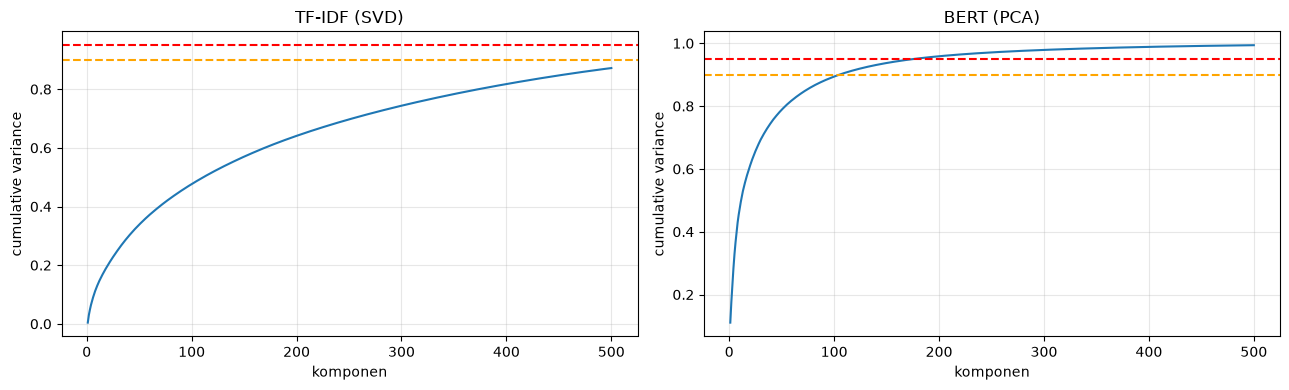

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler

vec = TfidfVectorizer(max_features=1000, ngram_range=(1,2), min_df=3) 
Xt = vec.fit_transform(tfidf_texts)
svd_a = TruncatedSVD(n_components=min(500, Xt.shape[1]-1), random_state=RANDOM_STATE).fit(Xt)
cum_t = np.cumsum(svd_a.explained_variance_ratio_)

Xb = StandardScaler().fit_transform(np.nan_to_num(bert))
pca_a = PCA(n_components=min(500, Xb.shape[1]), random_state=RANDOM_STATE).fit(Xb)
cum_b = np.cumsum(pca_a.explained_variance_ratio_)

for name, cum in [("TF-IDF (SVD)", cum_t), ("BERT (PCA)", cum_b)]:
    print(f"\n{name}:")
    for thr in [0.80, 0.90, 0.95]:
        k = int(np.searchsorted(cum, thr) + 1)
        print(f"   {int(thr*100)}% variance -> ~{k} komponen")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
for a,(name,cum) in zip(ax, [("TF-IDF (SVD)",cum_t),("BERT (PCA)",cum_b)]):
    a.plot(range(1,len(cum)+1), cum); a.axhline(.9, ls="--", c="orange"); a.axhline(.95, ls="--", c="red")
    a.set_title(name); a.set_xlabel("komponen"); a.set_ylabel("cumulative variance"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Tahap 5 - Pembentukan Matriks Fitur dan Definisi Pipeline

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

sty_cols  = [f"sty_{i}" for i in range(sty.shape[1])]
bert_cols = [f"bert_{i}" for i in range(bert.shape[1])]

Xdf = pd.DataFrame(bert, columns=bert_cols)
Xdf[sty_cols] = sty
Xdf["perplexity"] = ppl
Xdf["text"] = tfidf_texts
y = df["label"].astype(int).values
groups = df["source_id"].values
print("Xdf:", Xdf.shape, "| y:", y.shape, "| grup:", len(np.unique(groups)))

def build_preprocessor(svd_k=300, pca_k=150, max_features=1000):
    tfidf_branch = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features, ngram_range=(1,2), min_df=3)), 
        ("svd",   TruncatedSVD(n_components=svd_k, random_state=RANDOM_STATE)), # sparse -> tanpa centering
    ])
    bert_branch = Pipeline([
        ("imp", SimpleImputer(strategy="mean")), 
        ("sc",  StandardScaler()),  # centering utk PCA
        ("pca", PCA(n_components=pca_k, random_state=RANDOM_STATE)),    # dense
    ])
    sty_branch  = Pipeline([("imp", SimpleImputer(strategy="mean")), ("sc", StandardScaler())])
    perp_branch = Pipeline([("imp", SimpleImputer(strategy="mean")), ("sc", StandardScaler())])
    return ColumnTransformer([
        ("tfidf", tfidf_branch, "text"),
        ("bert",  bert_branch,  bert_cols),
        ("sty",   sty_branch,   sty_cols),
        ("perp",  perp_branch,  ["perplexity"]),
    ])

Xdf: (5979, 788) | y: (5979,) | grup: 3000


## Tahap 5.1 - Simpan Matriks Fitur

In [12]:

import numpy as np, pandas as pd
try:
    from IPython.display import display
except Exception:
    display = print

# nama fitur stylometry (ambil urutan kunci dari fungsi ekstraksi)
try:
    sty_names = list(extract_stylometric_features(df["text"].iloc[0]).keys())
    if len(sty_names) != sty.shape[1]:
        sty_names = [f"sty_{i}" for i in range(sty.shape[1])]
except Exception:
    sty_names = [f"sty_{i}" for i in range(sty.shape[1])]

# --- tabel RINGKAS: metadata + stylometry (bernama) + perplexity ---
meta_cols = [c for c in ["doc_id", "source_id", "source", "label", "n_words"] if c in df.columns]
fitur_ringkas = df[meta_cols].reset_index(drop=True).copy()
fitur_ringkas["preview_teks"] = df["text"].astype(str).str.slice(0, 80).values
for j, nm in enumerate(sty_names):
    fitur_ringkas[f"sty__{nm}"] = sty[:, j]
fitur_ringkas["perplexity"] = ppl

print("Dimensi fitur -> stylometry:", sty.shape, "| perplexity:", ppl.shape, "| IndoBERT:", bert.shape)
print(f"Total fitur numerik / artikel = {sty.shape[1]} (stylometry) + 1 (perplexity) + "
      f"{bert.shape[1]} (IndoBERT) = {sty.shape[1] + 1 + bert.shape[1]}")
print("\nContoh hasil transformasi teks -> numerik (10 baris pertama):")
display(fitur_ringkas.head(10))

# --- simpan CSV ringkas (untuk inspeksi) ---
fitur_ringkas.to_csv(str(RESULTS_DIR / "fitur_ekstraksi_ringkas.csv"), index=False)

# versi LENGKAP termasuk 768 dimensi IndoBERT (untuk reproduksibilitas)
bert_df = pd.DataFrame(bert, columns=bert_cols)
fitur_lengkap = pd.concat(
    [fitur_ringkas.drop(columns=["preview_teks"]).reset_index(drop=True), bert_df], axis=1)
fitur_lengkap.to_csv(str(RESULTS_DIR / "fitur_ekstraksi_lengkap.csv"), index=False)
print(f"\nDisimpan (inspeksi): fitur_ekstraksi_ringkas.csv ({fitur_ringkas.shape[1]} kolom) | "
      f"fitur_ekstraksi_lengkap.csv ({fitur_lengkap.shape[1]} kolom)")


train_df = Xdf.copy()
train_df.insert(0, "label", y)
train_df.insert(0, "source_id", groups)
if "doc_id" in df.columns:
    train_df.insert(0, "doc_id", df["doc_id"].values)
train_df.to_csv(str(RESULTS_DIR / "dataset_fitur_training.csv"), index=False)
print(f"\nCSV INPUT PELATIHAN disimpan -> dataset_fitur_training.csv "
      f"({train_df.shape[0]} baris x {train_df.shape[1]} kolom)")
print("   -> kolom: doc_id, source_id, label, {bert_0..bert_N}, {sty_0..sty_M}, perplexity, text")


Dimensi fitur -> stylometry: (5979, 18) | perplexity: (5979,) | IndoBERT: (5979, 768)
Total fitur numerik / artikel = 18 (stylometry) + 1 (perplexity) + 768 (IndoBERT) = 787

Contoh hasil transformasi teks -> numerik (10 baris pertama):


,doc_id,source_id,source,label,n_words,preview_teks,sty__char_count,sty__word_count,sty__sentence_count,sty__avg_sentence_length,...,sty__exclamation_mark_count,sty__period_count,sty__colon_count,sty__punctuation_ratio,sty__uppercase_ratio,sty__digit_ratio,sty__special_char_count,sty__special_char_ratio,sty__function_word_ratio,perplexity
0,0,0,id_newspapers_2018,0,301,"Setelah bergabung dengan Ducati, Jorge Lorenzo berharap ...",2043.0,301.0,13.0,23.153847,...,0.0,13.0,1.0,0.015663,0.033774,0.009300,46.0,0.022516,0.201987,61.540802
1,1,0,id_newspapers_2018,1,294,"Pebalap MotoGP legendaris, Jorge Lorenzo, kembali mencur...",2060.0,294.0,21.0,14.000000,...,0.0,21.0,0.0,0.018932,0.032039,0.002913,49.0,0.023786,0.204082,22.306870
2,2,1,id_newspapers_2018,0,285,Musisi Ahmad Dhani memenuhi panggilan Polda Metro Jaya u...,2028.0,285.0,20.0,14.250000,...,0.0,20.0,0.0,0.021203,0.063116,0.007396,58.0,0.028600,0.145329,69.760811
3,3,1,id_newspapers_2018,1,281,"Ahmad Dhani, personel grup band Dewa 19, mengaku tak mem...",1978.0,281.0,15.0,18.733334,...,0.0,15.0,0.0,0.014661,0.025278,0.002022,36.0,0.018200,0.198582,25.545443
4,4,2,id_newspapers_2018,0,365,Keputusan Presiden Joko Widodo menetapkan Kepala Badan N...,2599.0,365.0,21.0,17.380953,...,0.0,21.0,0.0,0.018084,0.062716,0.007695,74.0,0.028472,0.163043,54.138439
5,5,2,id_newspapers_2018,1,309,"Mantan Kepala Badan Reserse dan Kriminal Polri, Tito Kar...",2387.0,309.0,20.0,15.450000,...,0.0,20.0,0.0,0.014244,0.035191,0.001676,35.0,0.014663,0.212903,37.595905
6,6,3,id_newspapers_2018,0,230,Perusahaan semikonduktor Qualcomm mengumumkan kehadiran ...,1729.0,230.0,14.0,16.428572,...,0.0,13.0,0.0,0.015616,0.035281,0.013881,33.0,0.019086,0.220779,81.988342
7,7,3,id_newspapers_2018,1,316,Prosesor Snapdragon dipastikan semakin canggih dengan ke...,2346.0,316.0,21.0,15.047619,...,0.0,21.0,0.0,0.016624,0.018755,0.000000,44.0,0.018755,0.236760,19.784868
8,8,4,id_newspapers_2018,0,400,"Dari segi pariwisata, daya tarik Indonesia tidak bisa di...",2948.0,400.0,16.0,25.000000,...,0.0,16.0,0.0,0.018996,0.055970,0.017639,71.0,0.024084,0.178660,73.075119
9,9,4,id_newspapers_2018,1,291,Dewasa ini semakin banyak tempat wisata bahari yang mula...,2131.0,291.0,18.0,16.166666,...,0.0,18.0,0.0,0.011732,0.018771,0.000000,25.0,0.011732,0.240550,28.369240



Disimpan (inspeksi): fitur_ekstraksi_ringkas.csv (25 kolom) | fitur_ekstraksi_lengkap.csv (792 kolom)

CSV INPUT PELATIHAN disimpan -> dataset_fitur_training.csv (5979 baris x 791 kolom)
   -> kolom: doc_id, source_id, label, {bert_0..bert_N}, {sty_0..sty_M}, perplexity, text


## Tahap 5.2 - Muat Ulang Fitur dari CSV sebagai Input Pelatihan

In [13]:

import numpy as np, pandas as pd

TRAIN_CSV = str(RESULTS_DIR / "dataset_fitur_training.csv")
train_df = pd.read_csv(TRAIN_CSV)

# rekonstruksi daftar kolom fitur dari header CSV
bert_cols = sorted([c for c in train_df.columns if c.startswith("bert_")],
                   key=lambda c: int(c.split("_")[1]))
sty_cols  = sorted([c for c in train_df.columns if c.startswith("sty_")],
                   key=lambda c: int(c.split("_")[1]))
feat_cols = bert_cols + sty_cols + ["perplexity", "text"]

# kolom teks (bahan TF-IDF) jangan sampai NaN
train_df["text"] = train_df["text"].fillna("").astype(str)

# samakan tipe numerik dengan hasil ekstraksi asli (float32)
num_cols = bert_cols + sty_cols + ["perplexity"]
train_df[num_cols] = train_df[num_cols].astype(np.float32)

Xdf_csv    = train_df[feat_cols].copy()
y_csv      = train_df["label"].astype(int).values
groups_csv = train_df["source_id"].values

# --- BUKTI: identik dengan hasil ekstraksi di memori (hasil TIDAK berubah) ---
try:
    same_num  = np.allclose(Xdf_csv[num_cols].values, Xdf[num_cols].values.astype(np.float32),
                            rtol=1e-5, atol=1e-6, equal_nan=True)
    same_text = bool((Xdf_csv["text"].values == Xdf["text"].astype(str).values).all())
    same_y    = bool((y_csv == y).all())
    same_g    = bool((groups_csv == groups).all())
    
    if all([same_num, same_text, same_y, same_g]):
        print("OK: data dari CSV ")
except Exception as e:
    print("Lewati verifikasi (variabel memori tak tersedia):", e)

# --- jadikan CSV sebagai sumber data pelatihan untuk SEMUA sel berikutnya ---
Xdf, y, groups = Xdf_csv, y_csv, groups_csv
print(f"Input pelatihan  '{TRAIN_CSV}' -> Xdf: {Xdf.shape}, "
      f"grup unik: {len(np.unique(groups))}")


OK: data dari CSV 
Input pelatihan  'c:\Kuliah\SKRIPSI\setelah sempro\data_indo\push gihub\AI-Text-Detection\results\dataset_fitur_training.csv' -> Xdf: (5979, 788), grup unik: 3000


## Tahap 6.1 - Hasil Reduksi Dimensi dan Fusi Fitur (representasi tereduksi)

In [14]:

import numpy as np, pandas as pd
pd.set_option("display.width", 220)

# pakai kembali 'idx' & 'labels' dari sel 4.2; bentuk lagi bila belum ada
if ("idx" not in globals()) or ("labels" not in globals()):
    SAMPLE = [(1195, 0, "news-1195-human"), (1195, 1, "news-1195-ai"),
              (900, 0, "news-900-human"), (900, 1, "news-900-ai")]
    idx, labels = [], []
    for sid, lab, name in SAMPLE:
        m = df.index[(df["source_id"] == sid) & (df["label"] == lab)]
        idx.append(int(m[0])); labels.append(name)

_SVD = int(globals().get("BEST_SVD", 300))
_PCA = int(globals().get("BEST_PCA", 150))

# transformasi fusi penuh lalu potong per cabang (urutan CT: tfidf|bert|sty|perp)
_pre = build_preprocessor(_SVD, _PCA).fit(Xdf, y)
Z = np.asarray(_pre.transform(Xdf))
tfidf_red = Z[:, 0:_SVD]                 # TF-IDF setelah Truncated SVD
bert_red  = Z[:, _SVD:_SVD + _PCA]       # IndoBERT setelah StandardScaler+PCA

def _ringkas(mat, i, prefix, k_first=3):
    v = mat[i]
    d = {f"{prefix}-{j+1}": round(float(v[j]), 4) for j in range(k_first)}
    d["..."] = "..."
    d[f"{prefix}-{len(v)}"] = round(float(v[-1]), 4)
    return d

print("=== Tabel 4.6  Representasi TF-IDF setelah Truncated SVD (300 komponen) ===")
print(pd.DataFrame([dict(Dokumen=n, **_ringkas(tfidf_red, i, "SVD")) for n, i in zip(labels, idx)]).to_string(index=False))

print("\n=== Tabel 4.7  Representasi IndoBERT setelah PCA (150 komponen) ===")
print(pd.DataFrame([dict(Dokumen=n, **_ringkas(bert_red, i, "PCA")) for n, i in zip(labels, idx)]).to_string(index=False))

# --- Tabel 4.8  Komponen ambang ragam kumulatif (verifikasi 300 & 150) ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler
_RS = int(globals().get("RANDOM_STATE", 42))
_texts = globals().get("tfidf_texts") or [preprocess_for_tfidf(t) for t in df["text"].astype(str)]
_Xt = Xt if "Xt" in globals() else TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=3).fit_transform(_texts)
_svd = TruncatedSVD(n_components=min(500, _Xt.shape[1] - 1), random_state=_RS).fit(_Xt)
_cum_t = np.cumsum(_svd.explained_variance_ratio_)
_Xb = StandardScaler().fit_transform(np.nan_to_num(np.asarray(bert)))
_pca = PCA(n_components=min(500, _Xb.shape[1]), random_state=_RS).fit(_Xb)
_cum_b = np.cumsum(_pca.explained_variance_ratio_)
def _k(cum, thr):
    k = int(np.searchsorted(cum, thr) + 1)
    return str(k) if k <= len(cum) else f">{len(cum)}"
r48 = [{"Ambang ragam": f"{int(thr*100)}%", "TF-IDF (SVD)": _k(_cum_t, thr),
        "IndoBERT (PCA)": _k(_cum_b, thr)} for thr in [0.80, 0.90, 0.95]]
print("\n=== Tabel 4.8  Komponen Ambang Ragam Kumulatif ===")
print(pd.DataFrame(r48).to_string(index=False))
print(f"\nDipakai: TF-IDF -> {_SVD} komp | IndoBERT -> {_PCA} komp | "
      f"vektor fusi -> {tfidf_red.shape[1] + bert_red.shape[1] + 18 + 1} dimensi")


=== Tabel 4.6  Representasi TF-IDF setelah Truncated SVD (300 komponen) ===
        Dokumen  SVD-1   SVD-2  SVD-3 ...  SVD-300
news-1195-human 0.1699 -0.0698 0.0282 ...  -0.0016
   news-1195-ai 0.2171 -0.0422 0.0457 ...  -0.0278
 news-900-human 0.2235  0.5142 0.1580 ...  -0.0190
    news-900-ai 0.2651  0.4911 0.1371 ...  -0.0379

=== Tabel 4.7  Representasi IndoBERT setelah PCA (150 komponen) ===
        Dokumen   PCA-1   PCA-2    PCA-3 ...  PCA-150
news-1195-human 10.1247 -8.4985   7.7821 ...   1.1603
   news-1195-ai  5.7545  3.8663  -1.4060 ...   0.4121
 news-900-human -0.2805 -7.7720 -12.8386 ...   0.6269
    news-900-ai -5.0176 -6.1529 -10.2686 ...  -0.3920

=== Tabel 4.8  Komponen Ambang Ragam Kumulatif ===
Ambang ragam TF-IDF (SVD) IndoBERT (PCA)
         80%          374             54
         90%         >500            105
         95%         >500            176

Dipakai: TF-IDF -> 300 komp | IndoBERT -> 150 komp | vektor fusi -> 469 dimensi


## Tahap 7 - Cross-Validation GroupKFold untuk 3 Model

In [15]:
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

n_pos = int((y==1).sum()); n_neg = int((y==0).sum())
spw = n_neg / max(n_pos, 1)
print(f"manusia(0)={n_neg}, AI(1)={n_pos}, scale_pos_weight={spw:.2f}")

def make_models():
    return {
        "Random Forest": RandomForestClassifier(
            n_estimators=400, max_depth=12, min_samples_leaf=5, max_features="sqrt",
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            max_depth=4, learning_rate=0.05, n_estimators=400, subsample=0.8,
            colsample_bytree=0.8, min_child_weight=5, reg_lambda=2.0,
            scale_pos_weight=spw, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
        "CatBoost": CatBoostClassifier(
            depth=5, learning_rate=0.05, iterations=500, l2_leaf_reg=6,
            auto_class_weights="Balanced", random_state=RANDOM_STATE, verbose=0),
    }

SVD_K, PCA_K = 300, 150   # titik awal (dari analisis variance); dituning di Tahap 7
gkf = GroupKFold(n_splits=5)
scoring = ["accuracy","f1","f1_macro","roc_auc","balanced_accuracy","precision","recall"]

results = {}
perfold_rows = []   # <-- kinerja tiap fold
for name, model in make_models().items():
    pipe = Pipeline([("pre", build_preprocessor(SVD_K, PCA_K)), ("clf", model)])
    t0 = time.time()
    cv = cross_validate(pipe, Xdf, y, groups=groups, cv=gkf, scoring=scoring,
                        return_train_score=True, n_jobs=1)
    results[name] = {m: cv[f"test_{m}"].mean() for m in scoring}
    results[name]["train_f1_macro"] = cv["train_f1_macro"].mean()
    results[name]["gap_f1_macro"]  = cv["train_f1_macro"].mean() - cv["test_f1_macro"].mean()
    # rekam kinerja PER-FOLD
    for f in range(gkf.get_n_splits()):
        row = {"model": name, "fold": f + 1}
        for m in scoring:
            row[m] = round(float(cv[f"test_{m}"][f]), 4)
        row["train_f1_macro"] = round(float(cv["train_f1_macro"][f]), 4)
        row["gap_f1_macro"]   = round(float(cv["train_f1_macro"][f] - cv["test_f1_macro"][f]), 4)
        row["fit_time_s"]     = round(float(cv["fit_time"][f]), 1)
        perfold_rows.append(row)
    print(f"{name:14s} | F1-macro={results[name]['f1_macro']:.4f} | ROC-AUC={results[name]['roc_auc']:.4f} | "
          f"BalAcc={results[name]['balanced_accuracy']:.4f} | gap={results[name]['gap_f1_macro']:.3f} | {time.time()-t0:.0f}s")

# --- simpan & tampilkan kinerja per-fold ---
perfold_df = pd.DataFrame(perfold_rows)
perfold_df.to_csv(str(RESULTS_DIR / "kinerja_per_fold.csv"), index=False)
print("\nKinerja per-fold disimpan -> kinerja_per_fold.csv")
ringkas_fold = (perfold_df.groupby("model")[["f1_macro","roc_auc","balanced_accuracy","accuracy"]]
                .agg(["mean","std"]).round(4))
try:
    from IPython.display import display
    display(perfold_df)
    display(ringkas_fold)
except Exception:
    print(perfold_df); print(ringkas_fold)

pd.DataFrame(results).T.round(4)


manusia(0)=2979, AI(1)=3000, scale_pos_weight=0.99
Random Forest  | F1-macro=0.9722 | ROC-AUC=0.9967 | BalAcc=0.9723 | gap=0.025 | 54s
XGBoost        | F1-macro=0.9828 | ROC-AUC=0.9986 | BalAcc=0.9828 | gap=0.017 | 58s
CatBoost       | F1-macro=0.9838 | ROC-AUC=0.9983 | BalAcc=0.9838 | gap=0.016 | 93s

Kinerja per-fold disimpan -> kinerja_per_fold.csv


,model,fold,accuracy,f1,f1_macro,roc_auc,balanced_accuracy,precision,recall,train_f1_macro,gap_f1_macro,fit_time_s
0,Random Forest,1,0.9732,0.9731,0.9732,0.9973,0.9733,0.9830,0.9633,0.9973,0.0240,7.8
1,Random Forest,2,0.9732,0.9731,0.9732,0.9962,0.9733,0.9830,0.9633,0.9969,0.0236,8.3
2,Random Forest,3,0.9741,0.9739,0.9741,0.9961,0.9741,0.9830,0.9650,0.9973,0.0232,7.4
3,Random Forest,4,0.9732,0.9732,0.9732,0.9972,0.9733,0.9781,0.9683,0.9962,0.0230,6.8
4,Random Forest,5,0.9674,0.9670,0.9674,0.9969,0.9674,0.9811,0.9533,0.9962,0.0289,6.6
5,XGBoost,1,0.9808,0.9808,0.9808,0.9986,0.9808,0.9816,0.9800,1.0000,0.0192,8.3
6,XGBoost,2,0.9849,0.9849,0.9849,0.9983,0.9850,0.9932,0.9767,1.0000,0.0151,8.3
7,XGBoost,3,0.9816,0.9816,0.9816,0.9982,0.9816,0.9849,0.9783,1.0000,0.0184,8.2
8,XGBoost,4,0.9841,0.9841,0.9841,0.9990,0.9841,0.9866,0.9817,1.0000,0.0159,9.5
9,XGBoost,5,0.9824,0.9824,0.9824,0.9990,0.9825,0.9898,0.9750,1.0000,0.0176,8.7


f1_macro         roc_auc         balanced_accuracy         accuracy        
                  mean     std    mean     std              mean     std     mean     std
model                                                                                    
CatBoost        0.9838  0.0015  0.9983  0.0006            0.9838  0.0015   0.9838  0.0015
Random Forest   0.9722  0.0027  0.9967  0.0006            0.9723  0.0027   0.9722  0.0027
XGBoost         0.9828  0.0017  0.9986  0.0004            0.9828  0.0017   0.9828  0.0017

,accuracy,f1,f1_macro,roc_auc,balanced_accuracy,precision,recall,train_f1_macro,gap_f1_macro
Random Forest,0.9722,0.9721,0.9722,0.9967,0.9723,0.9817,0.9627,0.9968,0.0245
XGBoost,0.9828,0.9828,0.9828,0.9986,0.9828,0.9872,0.9783,1.0000,0.0172
CatBoost,0.9838,0.9838,0.9838,0.9983,0.9838,0.9866,0.9810,1.0000,0.0162


## Tahap 7.5 - Eksperimen Jumlah Komponen (SVD & PCA)

In [16]:
grid = []
for svd_k in [100, 200, 300]:
    for pca_k in [50, 100, 150]:
        pipe = Pipeline([("pre", build_preprocessor(svd_k, pca_k)),
                         ("clf", make_models()["CatBoost"])])
        cv = cross_validate(pipe, Xdf, y, groups=groups, cv=gkf,
                            scoring=["f1_macro"], return_train_score=True, n_jobs=1)
        test_f1 = cv["test_f1_macro"].mean(); gap = cv["train_f1_macro"].mean() - test_f1
        grid.append({"svd_k": svd_k, "pca_k": pca_k, "dim_total": svd_k+pca_k+19,
                     "test_f1_macro": round(test_f1,4), "gap": round(gap,3)})
        print(f"svd={svd_k:3d} pca={pca_k:3d} (total {svd_k+pca_k+19:3d}) -> F1-macro={test_f1:.4f} gap={gap:.3f}")

grid_df = pd.DataFrame(grid).sort_values("test_f1_macro", ascending=False)
best = grid_df.iloc[0]
print("\nKombinasi terbaik:"); print(best)
BEST_SVD, BEST_PCA = int(best["svd_k"]), int(best["pca_k"])
grid_df

svd=100 pca= 50 (total 169) -> F1-macro=0.9829 gap=0.017
svd=100 pca=100 (total 219) -> F1-macro=0.9834 gap=0.017
svd=100 pca=150 (total 269) -> F1-macro=0.9833 gap=0.017
svd=200 pca= 50 (total 269) -> F1-macro=0.9831 gap=0.017
svd=200 pca=100 (total 319) -> F1-macro=0.9824 gap=0.018
svd=200 pca=150 (total 369) -> F1-macro=0.9826 gap=0.017
svd=300 pca= 50 (total 369) -> F1-macro=0.9826 gap=0.017
svd=300 pca=100 (total 419) -> F1-macro=0.9823 gap=0.018
svd=300 pca=150 (total 469) -> F1-macro=0.9838 gap=0.016

Kombinasi terbaik:
svd_k            300.0000
pca_k            150.0000
dim_total        469.0000
test_f1_macro      0.9838
gap                0.0160
Name: 8, dtype: float64


,svd_k,pca_k,dim_total,test_f1_macro,gap
8,300,150,469,0.9838,0.016
1,100,100,219,0.9834,0.017
2,100,150,269,0.9833,0.017
3,200,50,269,0.9831,0.017
0,100,50,169,0.9829,0.017
6,300,50,369,0.9826,0.017
5,200,150,369,0.9826,0.017
4,200,100,319,0.9824,0.018
7,300,100,419,0.9823,0.018


## Tahap 8 - Studi Ablasi 15 Kombinasi Fitur × 3 Model

In [17]:
import itertools, os, time
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, balanced_accuracy_score)

PERFOLD_KOMBINASI   = str(RESULTS_DIR / "kinerja_per_fold_kombinasi.csv")
RINGKASAN_KOMBINASI = str(RESULTS_DIR / "ringkasan_kombinasi_model.csv")

# pakai hasil tuning bila ada, kalau tidak pakai default
_SVD_K = int(globals().get("BEST_SVD", 300))
_PCA_K = int(globals().get("BEST_PCA", 150))
print(f"Reduksi dipakai -> SVD_K={_SVD_K}, PCA_K={_PCA_K}")

# 4 keluarga fitur -> semua kombinasi ukuran 1..4 (4 + 6 + 4 + 1 = 15)
ALL_FEATS = ["sty", "tfidf", "bert", "perp"]
COMBOS = [list(c) for r in range(1, len(ALL_FEATS)+1)
                  for c in itertools.combinations(ALL_FEATS, r)]
MODEL_NAMES = list(make_models().keys())   # ["Random Forest", "XGBoost", "CatBoost"]
print(f"{len(COMBOS)} kombinasi x {len(MODEL_NAMES)} model = {len(COMBOS)*len(MODEL_NAMES)} konfigurasi x 5 fold")

# --- resume: lewati konfigurasi yang sudah pernah dihitung ---
if os.path.exists(PERFOLD_KOMBINASI):
    _prev = pd.read_csv(PERFOLD_KOMBINASI)
    selesai = set(zip(_prev["kombinasi"], _prev["model"]))
    perfold_rows = _prev.to_dict("records")
    print(f"Melanjutkan. Sudah selesai: {len(selesai)} konfigurasi.")
else:
    perfold_rows, selesai = [], set()

for combo in COMBOS:
    combo_name = "+".join(combo)
    for model_name in MODEL_NAMES:
        if (combo_name, model_name) in selesai:
            continue
        t0 = time.time()
        for fold, (tr, va) in enumerate(gkf.split(Xdf, y, groups), start=1):
            pipe = Pipeline([("pre", build_preprocessor_subset(combo, _SVD_K, _PCA_K)),
                             ("clf", make_models()[model_name])])
            pipe.fit(Xdf.iloc[tr], y[tr])
            pred = pipe.predict(Xdf.iloc[va])
            prob = pipe.predict_proba(Xdf.iloc[va])[:, 1]
            perfold_rows.append({
                "kombinasi": combo_name, "n_fitur": len(combo),
                "model": model_name, "fold": fold,
                "f1_macro":   round(f1_score(y[va], pred, average="macro"), 4),
                "f1_AI":      round(f1_score(y[va], pred), 4),
                "akurasi":    round(accuracy_score(y[va], pred), 4),
                "presisi_AI": round(precision_score(y[va], pred, zero_division=0), 4),
                "recall_AI":  round(recall_score(y[va], pred, zero_division=0), 4),
                "bal_acc":    round(balanced_accuracy_score(y[va], pred), 4),
                "roc_auc":    round(roc_auc_score(y[va], prob), 4),
            })
        # simpan checkpoint hasil setelah tiap konfigurasi (5 fold) selesai
        pd.DataFrame(perfold_rows).to_csv(PERFOLD_KOMBINASI, index=False)
        _f1 = np.mean([r["f1_macro"] for r in perfold_rows
                       if r["kombinasi"] == combo_name and r["model"] == model_name])
        print(f"{combo_name:20s} | {model_name:14s} | F1-macro={_f1:.4f} | {time.time()-t0:.0f}s")

# --- ringkasan rata-rata 5 fold per konfigurasi ---
perfold_df = pd.DataFrame(perfold_rows)
ringkasan = (perfold_df.groupby(["kombinasi", "n_fitur", "model"])
             .agg(f1_macro_mean=("f1_macro", "mean"), f1_macro_std=("f1_macro", "std"),
                  roc_auc_mean=("roc_auc", "mean"), bal_acc_mean=("bal_acc", "mean"),
                  recall_AI_mean=("recall_AI", "mean"), presisi_AI_mean=("presisi_AI", "mean"))
             .reset_index()
             .sort_values(["f1_macro_mean", "f1_macro_std"], ascending=[False, True])
             .reset_index(drop=True))
ringkasan.to_csv(RINGKASAN_KOMBINASI, index=False)
print("\nDisimpan: kinerja_per_fold_kombinasi.csv (per-fold) + ringkasan_kombinasi_model.csv")
print("\n=== 10 konfigurasi terbaik (rata-rata 5 fold) ===")
try:
    from IPython.display import display
    display(ringkasan.head(10))
except Exception:
    print(ringkasan.head(10).to_string(index=False))


Reduksi dipakai -> SVD_K=300, PCA_K=150
15 kombinasi x 3 model = 45 konfigurasi x 5 fold
Melanjutkan. Sudah selesai: 45 konfigurasi.

Disimpan: kinerja_per_fold_kombinasi.csv (per-fold) + ringkasan_kombinasi_model.csv

=== 10 konfigurasi terbaik (rata-rata 5 fold) ===


,kombinasi,n_fitur,model,f1_macro_mean,f1_macro_std,roc_auc_mean,bal_acc_mean,recall_AI_mean,presisi_AI_mean
0,sty+tfidf+bert+perp,4,CatBoost,0.98378,0.001522,0.99834,0.98378,0.98098,0.98660
1,sty+bert+perp,3,CatBoost,0.98292,0.002390,0.99830,0.98294,0.98066,0.98526
2,sty+tfidf+bert+perp,4,XGBoost,0.98276,0.001710,0.99862,0.98280,0.97834,0.98722
3,sty+tfidf+perp,3,CatBoost,0.98144,0.002240,0.99788,0.98144,0.97864,0.98424
4,sty+bert+perp,3,XGBoost,0.98076,0.003904,0.99852,0.98076,0.97798,0.98358
5,sty+tfidf+perp,3,XGBoost,0.98026,0.003473,0.99790,0.98028,0.97534,0.98522
6,tfidf+bert+perp,3,CatBoost,0.97860,0.004967,0.99740,0.97860,0.97966,0.97772
7,tfidf+bert+perp,3,XGBoost,0.97710,0.004692,0.99770,0.97710,0.97764,0.97674
8,bert+perp,2,XGBoost,0.97692,0.005107,0.99746,0.97694,0.97666,0.97736
9,bert+perp,2,CatBoost,0.97526,0.006457,0.99710,0.97526,0.97432,0.97632


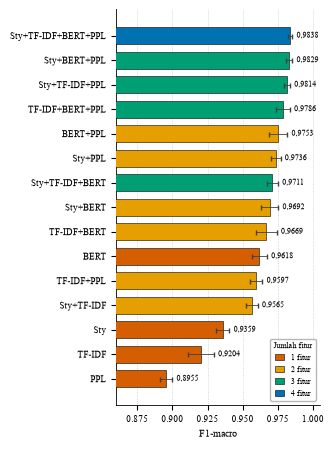

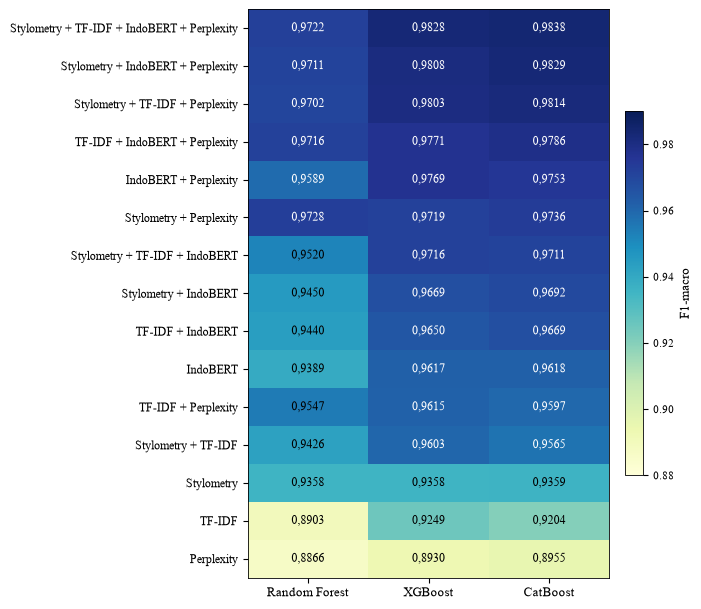

Random Forest   terbaik = 0,9728  <- sty+perp
XGBoost         terbaik = 0,9828  <- sty+tfidf+bert+perp
CatBoost        terbaik = 0,9838  <- sty+tfidf+bert+perp


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------- konfigurasi ----------------
MODEL_UTAMA = "CatBoost"
SATU_KOLOM  = True     # True = lebar 1 kolom (3.4"); False = 2 kolom (7.1")
MODEL_ORDER = ["Random Forest", "XGBoost", "CatBoost"]

SINGKAT = {"sty": "Sty", "tfidf": "TF-IDF", "bert": "BERT", "perp": "PPL"}
PANJANG = {"sty": "Stylometry", "tfidf": "TF-IDF",
           "bert": "IndoBERT", "perp": "Perplexity"}
# palet Okabe-Ito 
WARNA = {1: "#D55E00", 2: "#E69F00", 3: "#009E73", 4: "#0072B2"}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.linewidth": 0.6,
})

def _koma(x, nd=4):
    return f"{x:.{nd}f}".replace(".", ",")

# ---------------- ambil data ----------------
if "ringkasan" in globals():
    df = ringkasan.copy()
elif "ringkasan_kombinasi_model" in globals():
    df = ringkasan_kombinasi_model.copy()
else:
    df = pd.read_csv(str(RESULTS_DIR / "ringkasan_kombinasi_model.csv"))
df.columns = df.columns.str.strip()

W  = 3.4 if SATU_KOLOM else 7.1
FS = 6.5 if SATU_KOLOM else 8.5

# 1) Fig. 1

d = df[df["model"] == MODEL_UTAMA].copy()
d["label"] = d["kombinasi"].apply(
    lambda s: "+".join(SINGKAT[t] for t in s.split("+")))
d = d.sort_values("f1_macro_mean").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(W, 4.6))      # <- ax TUNGGAL, bukan array
warna = [WARNA[int(n)] for n in d["n_fitur"]]

ax.barh(range(len(d)), d["f1_macro_mean"], xerr=d["f1_macro_std"],
        color=warna, edgecolor="black", linewidth=0.4, height=0.7,
        error_kw={"elinewidth": 0.6, "capsize": 1.8, "ecolor": "0.25"},
        zorder=3)

for i, (m, s) in enumerate(zip(d["f1_macro_mean"], d["f1_macro_std"])):
    ax.text(m + s + 0.003, i, _koma(m), va="center", fontsize=FS - 0.5)

ax.set_yticks(range(len(d)))
ax.set_yticklabels(d["label"], fontsize=FS)
ax.set_xlabel("F1-macro", fontsize=FS + 1)
ax.set_xlim(0.86, 1.005)
ax.tick_params(axis="x", labelsize=FS)
ax.grid(axis="x", ls=":", lw=0.5, color="0.75", zorder=0)
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

leg = [Patch(facecolor=WARNA[k], edgecolor="black", linewidth=0.4,
             label=f"{k} fitur") for k in (1, 2, 3, 4)]
ax.legend(handles=leg, fontsize=FS - 0.5, title="Jumlah fitur",
          title_fontsize=FS - 0.5, loc="lower right", frameon=True,
          framealpha=0.95, edgecolor="0.7", borderpad=0.4, handlelength=1.1)

fig.tight_layout()
fig.savefig(str(FIGURES_DIR / "ablasi_bar_warna.png"), dpi=300, bbox_inches="tight")
plt.show()

piv = (df.pivot_table(index="kombinasi", columns="model",
                      values="f1_macro_mean")
         .reindex(columns=MODEL_ORDER)
         .sort_values("CatBoost", ascending=False))
ylabels = [" + ".join(PANJANG[t] for t in k.split("+")) for k in piv.index]
data = piv.values

fig, ax = plt.subplots(figsize=(7.1, 6.2))    # <- ax TUNGGAL juga
im = ax.imshow(data, cmap="YlGnBu", aspect="auto", vmin=0.88, vmax=0.99)

ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9)
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=8.5)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        ax.text(j, i, _koma(v), ha="center", va="center", fontsize=8.5,
                color=("white" if v > 0.955 else "black"))

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("F1-macro", fontsize=9)
cbar.ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / "matriks_ablasi_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---------------- ringkasan teks ----------------
for m in MODEL_ORDER:
    sub = df[df["model"] == m].set_index("kombinasi")["f1_macro_mean"]
    print(f"{m:<15} terbaik = {_koma(sub.max())}  <- {sub.idxmax()}")

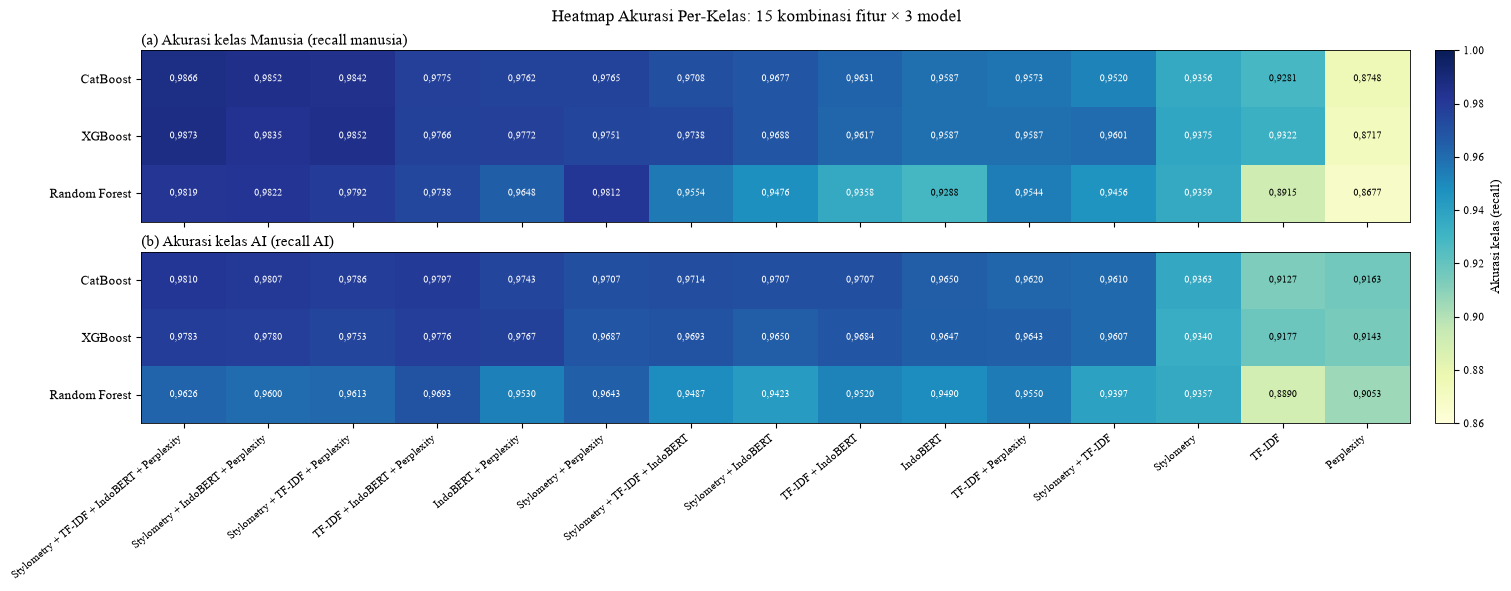

=== Akurasi kelas MANUSIA (rata-rata OOF 5 fold) ===
kombinasi      sty+tfidf+bert+perp  sty+bert+perp  sty+tfidf+perp  tfidf+bert+perp  bert+perp  sty+perp  sty+tfidf+bert  sty+bert  tfidf+bert    bert  tfidf+perp  sty+tfidf     sty   tfidf    perp
model                                                                                                                                                                                               
CatBoost                    0.9866         0.9852          0.9842           0.9775     0.9762    0.9765          0.9708    0.9677      0.9631  0.9587      0.9573     0.9520  0.9356  0.9281  0.8748
XGBoost                     0.9873         0.9835          0.9852           0.9766     0.9772    0.9751          0.9738    0.9688      0.9617  0.9587      0.9587     0.9601  0.9375  0.9322  0.8717
Random Forest               0.9819         0.9822          0.9792           0.9738     0.9648    0.9812          0.9554    0.9476      0.9358  0.9288      0.95

In [19]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

MODEL_ORDER = ["CatBoost", "XGBoost", "Random Forest"]      # atas -> bawah
PANJANG = {"sty": "Stylometry", "tfidf": "TF-IDF", "bert": "IndoBERT", "perp": "Perplexity"}

plt.rcParams.update({"font.family": "serif",
                     "font.serif": ["Times New Roman", "DejaVu Serif"]})

# --- ambil data per-fold hasil studi ablasi ---------------------------------
_need = {"kombinasi", "model", "bal_acc", "recall_AI", "f1_macro"}
if "perfold_df" in globals() and _need.issubset(set(getattr(perfold_df, "columns", []))):
    _pf = perfold_df.copy()
else:
    _pf = pd.read_csv(str(RESULTS_DIR / "kinerja_per_fold_kombinasi.csv"))
_pf.columns = _pf.columns.str.strip()

# --- akurasi per-kelas per fold -> rata-rata 5 fold -------------------------
_pf["akurasi_AI"]      = _pf["recall_AI"]
_pf["akurasi_manusia"] = 2.0 * _pf["bal_acc"] - _pf["recall_AI"]
agg = (_pf.groupby(["kombinasi", "model"])
          .agg(akurasi_manusia=("akurasi_manusia", "mean"),
               akurasi_AI=("akurasi_AI", "mean"),
               f1_macro=("f1_macro", "mean"))
          .reset_index())

def _label(k):
    return " + ".join(PANJANG.get(t, t) for t in k.split("+"))
def _koma(x):
    return f"{x:.4f}".replace(".", ",")

# urutan kombinasi mengikuti F1-macro CatBoost (sama seperti Gambar 4.2)
order_cat = (agg[agg["model"] == "CatBoost"]
             .sort_values("f1_macro", ascending=False)["kombinasi"].tolist())

def _matrix(col):
    return (agg.pivot(index="model", columns="kombinasi", values=col)
               .reindex(index=MODEL_ORDER, columns=order_cat))

M_man = _matrix("akurasi_manusia")
M_ai  = _matrix("akurasi_AI")
xlab  = [_label(k) for k in order_cat]

# --- gambar: dua panel mendatar (manusia atas, AI bawah) berbagi sumbu-x ----
vmin = float(np.nanmin([M_man.values.min(), M_ai.values.min()]))
vmin = np.floor(vmin * 100) / 100.0
vmax = 1.0
fig, axes = plt.subplots(2, 1, figsize=(15, 5.8), sharex=True,
                         constrained_layout=True)
panels = [("(a) Akurasi kelas Manusia (recall manusia)", M_man),
          ("(b) Akurasi kelas AI (recall AI)", M_ai)]
im = None
for ax, (judul, M) in zip(axes, panels):
    im = ax.imshow(M.values, cmap="YlGnBu", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(MODEL_ORDER)))
    ax.set_yticklabels(MODEL_ORDER, fontsize=9)
    ax.set_title(judul, fontsize=10.5, loc="left", pad=4)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            ax.text(j, i, _koma(v), ha="center", va="center", fontsize=7.2,
                    color=("white" if v > (vmin + vmax) / 2 else "black"))
axes[-1].set_xticks(range(len(xlab)))
axes[-1].set_xticklabels(xlab, rotation=40, ha="right", fontsize=8)
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Akurasi kelas (recall)", fontsize=9)
cbar.ax.tick_params(labelsize=8)
fig.suptitle("Heatmap Akurasi Per-Kelas: 15 kombinasi fitur \u00d7 3 model", fontsize=12)
fig.savefig(str(FIGURES_DIR / "gambar_4_4_heatmap_akurasi_perkelas.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- cetak tabel + simpan CSV (agar mudah disalin ke buku) ------------------
print("=== Akurasi kelas MANUSIA (rata-rata OOF 5 fold) ===")
print(M_man.round(4).to_string())
print("\n=== Akurasi kelas AI (rata-rata OOF 5 fold) ===")
print(M_ai.round(4).to_string())
_out = agg.copy()
_out["kombinasi_label"] = _out["kombinasi"].map(_label)
_out = _out[["kombinasi_label", "model", "akurasi_manusia", "akurasi_AI", "f1_macro"]].round(4)
_out.to_csv(str(RESULTS_DIR / "akurasi_perkelas_semua_kombinasi.csv"), index=False, encoding="utf-8-sig")
print("\nDisimpan: gambar_4_4_heatmap_akurasi_perkelas.png + akurasi_perkelas_semua_kombinasi.csv")


## Tahap 9 - Evaluasi OOF dan Diagnostik Model

              precision    recall  f1-score   support

     manusia     0.9810    0.9866    0.9838      2979
          AI     0.9866    0.9810    0.9838      3000

    accuracy                         0.9838      5979
   macro avg     0.9838    0.9838    0.9838      5979
weighted avg     0.9838    0.9838    0.9838      5979

ROC-AUC (OOF): 0.9983
Overfitting cek -> train F1-macro=1.0000 vs OOF F1-macro=0.9838


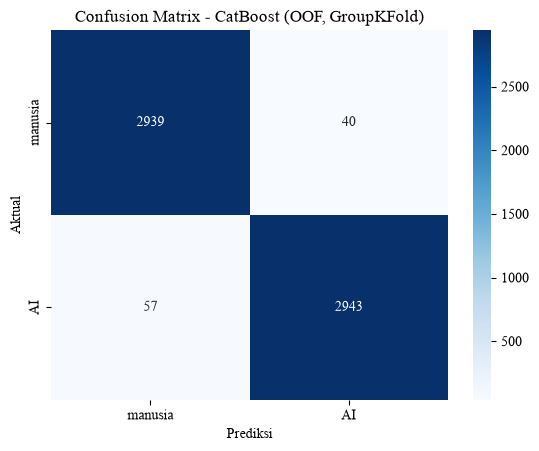

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import seaborn as sns
BEST_SVD = 300
BEST_PCA = 150
MODEL_FINAL = "CatBoost"   # ganti sesuai model terbaik di Tahap 6
oof_pred = np.zeros(len(y)); oof_prob = np.zeros(len(y))
train_f1s = []
for tr, te in gkf.split(Xdf, y, groups):
    pipe = Pipeline([("pre", build_preprocessor(BEST_SVD, BEST_PCA)), ("clf", make_models()[MODEL_FINAL])])
    pipe.fit(Xdf.iloc[tr], y[tr])
    oof_pred[te] = pipe.predict(Xdf.iloc[te])
    oof_prob[te] = pipe.predict_proba(Xdf.iloc[te])[:,1]
    train_f1s.append(f1_score(y[tr], pipe.predict(Xdf.iloc[tr]), average="macro"))

print(classification_report(y, oof_pred, target_names=["manusia","AI"], digits=4))
print("ROC-AUC (OOF):", round(roc_auc_score(y, oof_prob), 4))
print(f"Overfitting cek -> train F1-macro={np.mean(train_f1s):.4f} vs OOF F1-macro={f1_score(y,oof_pred,average='macro'):.4f}")

cm = confusion_matrix(y, oof_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["manusia","AI"], yticklabels=["manusia","AI"])
plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.title(f"Confusion Matrix - {MODEL_FINAL} (OOF, GroupKFold)"); plt.show()

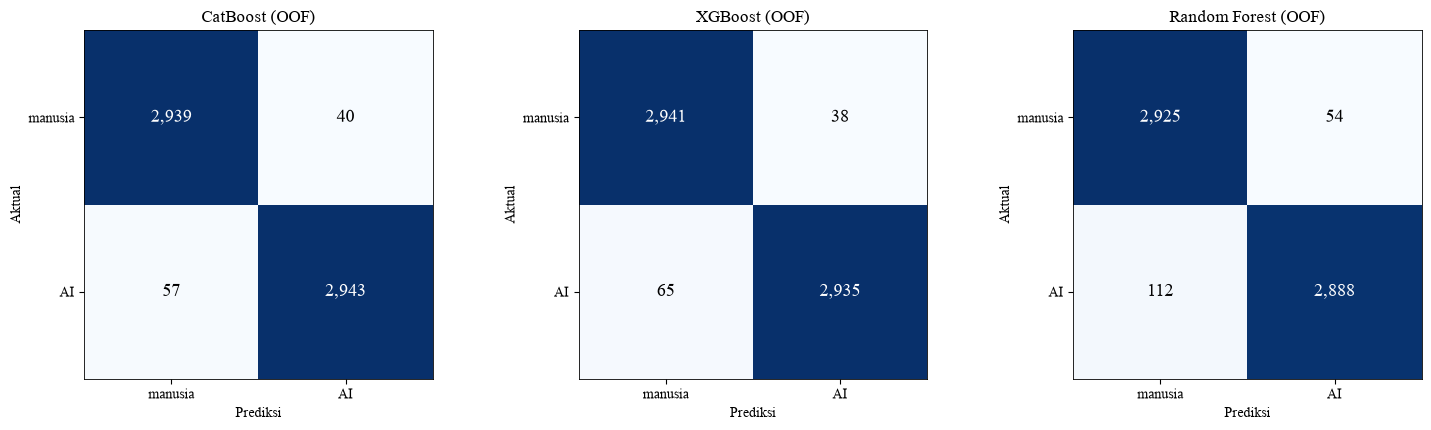

=== Tabel diagnostik metrik 3 model (fusi penuh 469 dimensi) ===
                                                                 CatBoost          XGBoost    Random Forest
F1-macro (validasi silang, rata-rata dan simpangan baku)  0,9838 ± 0,0014  0,9828 ± 0,0015  0,9722 ± 0,0024
F1-macro (out-of-fold gabungan)                                    0,9838           0,9828           0,9722
ROC-AUC                                                            0,9983           0,9986           0,9967
Precision kelas AI (out-of-fold)                                   0,9866           0,9872           0,9816
Recall kelas AI (out-of-fold)                                      0,9810           0,9783           0,9627
F1-macro data latih                                                1,0000           1,0000           0,9968
Selisih latih-validasi                                             0,0162           0,0172           0,0245

=== Tabel per-kelas 3 model (fusi penuh 469 dimensi) ===
             

In [21]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, f1_score, roc_auc_score,
                             accuracy_score, precision_score, recall_score)

ORDER   = ["CatBoost", "XGBoost", "Random Forest"]
CLASSES = ["manusia", "AI"]
y_true  = np.asarray(y).astype(int)

# --- guard: pastikan dict `oof` (pred, prob) tersedia utk ketiga model --------
if "oof" not in globals():
    from sklearn.pipeline import Pipeline
    _S = int(globals().get("BEST_SVD", 300)); _P = int(globals().get("BEST_PCA", 150))
    oof = {}
    for m in ORDER:
        pr_pred = np.zeros(len(y)); pr_prob = np.zeros(len(y))
        for tr, te in gkf.split(Xdf, y, groups):
            pipe = Pipeline([("pre", build_preprocessor(_S, _P)), ("clf", make_models()[m])])
            pipe.fit(Xdf.iloc[tr], y[tr])
            pr_pred[te] = pipe.predict(Xdf.iloc[te])
            pr_prob[te] = pipe.predict_proba(Xdf.iloc[te])[:, 1]
        oof[m] = (pr_pred.astype(int), pr_prob)

def _koma(x, nd=4):
    return f"{x:.{nd}f}".replace(".", ",")


fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, name in zip(axes, ORDER):
    pred = np.asarray(oof[name][0]).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} (OOF)", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(CLASSES)
    ax.set_yticks([0, 1]); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
    vmax = cm.max()
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm[r, c]:,}", ha="center", va="center", fontsize=13,
                    color="white" if cm[r, c] > vmax / 2 else "black")
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "gambar_4_3_cm_3model_oof.png"), dpi=150, bbox_inches="tight")
plt.show()


cv = {}
try:
    _cv = pd.read_csv(str(RESULTS_DIR / "kinerja_per_fold.csv"))
    _cv.columns = _cv.columns.str.strip()
    gb = _cv.groupby("model")
    for m in ORDER:
        gm = gb.get_group(m)
        cv[m] = {
            "f1_cv_mean": float(gm["f1_macro"].mean()),
            "f1_cv_std":  float(gm["f1_macro"].std(ddof=0)),
            "f1_train":   float(gm["train_f1_macro"].mean()),
            "gap":        float(gm["gap_f1_macro"].mean()),
        }
except Exception as e:
    print("[info] kinerja_per_fold.csv tak terbaca, memakai dict `results` bila ada:", e)
    for m in ORDER:
        r = globals().get("results", {}).get(m, {})
        cv[m] = {"f1_cv_mean": r.get("f1_macro", float("nan")), "f1_cv_std": float("nan"),
                 "f1_train": r.get("train_f1_macro", float("nan")), "gap": r.get("gap_f1_macro", float("nan"))}

# 2b) metrik OOF gabungan dari dict `oof`
METRIK = [
    "F1-macro (validasi silang, rata-rata dan simpangan baku)",
    "F1-macro (out-of-fold gabungan)",
    "ROC-AUC",
    "Precision kelas AI (out-of-fold)",
    "Recall kelas AI (out-of-fold)",
    "F1-macro data latih",
    "Selisih latih-validasi",
]
cols = {}
for m in ORDER:
    pred = np.asarray(oof[m][0]).astype(int)
    prob = np.asarray(oof[m][1])
    cols[m] = [
        f"{_koma(cv[m]['f1_cv_mean'])} \u00b1 {_koma(cv[m]['f1_cv_std'])}",
        _koma(f1_score(y_true, pred, average="macro")),
        _koma(roc_auc_score(y_true, prob)),
        _koma(precision_score(y_true, pred, pos_label=1)),
        _koma(recall_score(y_true, pred, pos_label=1)),
        _koma(cv[m]["f1_train"]),
        _koma(cv[m]["gap"]),
    ]
tab_diag = pd.DataFrame(cols, index=METRIK)[ORDER]
print("=== Tabel diagnostik metrik 3 model (fusi penuh 469 dimensi) ===")
print(tab_diag.to_string())
tab_diag.to_csv(str(RESULTS_DIR / "tabel_metrik_diagnostik_3model.csv"), encoding="utf-8-sig")


rows = []
for name in ORDER:
    pred = np.asarray(oof[name][0]).astype(int)
    prob = np.asarray(oof[name][1])
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    rows.append({
        "Model": name,
        "Akurasi":         round(accuracy_score(y_true, pred), 4),
        "Akurasi Manusia": round(tn / (tn + fp), 4),   # recall kelas manusia = TN/(TN+FP)
        "Akurasi AI":      round(tp / (tp + fn), 4),   # recall kelas AI      = TP/(TP+FN)
        "Presisi Manusia": round(tn / (tn + fn), 4),
        "Presisi AI":      round(tp / (tp + fp), 4),
        "F1-macro":        round(f1_score(y_true, pred, average="macro"), 4),
        "ROC-AUC":         round(roc_auc_score(y_true, prob), 4),
        "FP": int(fp), "FN": int(fn),
    })
tab_perkelas = pd.DataFrame(rows).set_index("Model")
pd.set_option("display.width", 220)
print("\n=== Tabel per-kelas 3 model (fusi penuh 469 dimensi) ===")
print(tab_perkelas.to_string())
tab_perkelas.to_csv(str(RESULTS_DIR / "tabel_perkelas_3model_oof.csv"), encoding="utf-8-sig")
print("\nCatatan: 'Akurasi Manusia' = recall kelas manusia = TN/(TN+FP);",
      "'Akurasi AI' = recall kelas AI = TP/(TP+FN).")


In [22]:
# ===== Salah prediksi - UJI VALIDASI (OOF) [v2, baca metadata dari CSV] =====
LABEL_NAMA = {0: "manusia", 1: "AI"}

# 1) hasil OOF (selaras dg y / oof_pred / groups)
hasil_oof = pd.DataFrame({
    "source_id":    groups,
    "label_aktual": y.astype(int),
    "prediksi":     oof_pred.astype(int),
    "prob_AI":      np.round(oof_prob, 4),
})

# 2) metadata ASLI dibaca ULANG dari CSV mentah (tak bergantung 'df' di memori)
RAW_PATH = globals().get("RAW_PATH", str(DATA_DIR / "dataset_berita_clean.csv"))   # sesuaikan bila perlu
_meta = pd.read_csv(RAW_PATH)
_meta.columns = _meta.columns.str.strip()
_MAP = {"human":0,"manusia":0,"asli":0,"real":0,"0":0,"0.0":0,
        "ai":1,"gpt":1,"chatgpt":1,"mesin":1,"1":1,"1.0":1}
_meta["label_aktual"] = _meta["label"].astype(str).str.strip().str.lower().map(_MAP)
_meta = _meta.dropna(subset=["label_aktual"])
_meta["label_aktual"] = _meta["label_aktual"].astype(int)
_keep = {"id":"doc_id", "text":"text", "model":"model", "source":"source"}
_cols = ["source_id", "label_aktual"] + [k for k in _keep if k in _meta.columns]
_meta = _meta[_cols].rename(columns=_keep)
_meta = _meta.drop_duplicates(subset=["source_id", "label_aktual"])

hasil_oof = hasil_oof.merge(_meta, on=["source_id", "label_aktual"], how="left")

# 3) tandai benar/salah + jenis kesalahan
hasil_oof["benar"] = hasil_oof["label_aktual"] == hasil_oof["prediksi"]
def _jenis(r):
    if r["benar"]:
        return "benar"
    return "FP (manusia dikira AI)" if r["label_aktual"] == 0 else "FN (AI dikira manusia)"
hasil_oof["jenis_kesalahan"]  = hasil_oof.apply(_jenis, axis=1)
hasil_oof["label_aktual_str"] = hasil_oof["label_aktual"].map(LABEL_NAMA)
hasil_oof["prediksi_str"]     = hasil_oof["prediksi"].map(LABEL_NAMA)
hasil_oof["cuplikan_teks"]    = hasil_oof.get("text", pd.Series([""]*len(hasil_oof))).astype(str).str.slice(0, 160)

# 4) subset SALAH saja, urut dari yang paling "yakin tapi salah"
kolom = [c for c in ["doc_id","source_id","source","model","label_aktual_str",
         "prediksi_str","jenis_kesalahan","prob_AI","cuplikan_teks","text"]
         if c in hasil_oof.columns]
salah_oof = hasil_oof[~hasil_oof["benar"]].copy()
salah_oof["keyakinan_salah"] = (salah_oof["prob_AI"] - 0.5).abs()
salah_oof = salah_oof.sort_values("keyakinan_salah", ascending=False)[kolom]

# 5) simpan CSV
hasil_oof[kolom].to_csv(str(RESULTS_DIR / "prediksi_validasi_lengkap.csv"), index=False)
salah_oof.to_csv(str(RESULTS_DIR / "salah_prediksi_validasi.csv"), index=False)

print("=== SALAH PREDIKSI - UJI VALIDASI (OOF) ===")
print(f"Total salah tebak : {len(salah_oof)} dari {len(hasil_oof)} dokumen")
print(f"Metadata tercocok : {hasil_oof['text'].notna().sum()} / {len(hasil_oof)}")
print(salah_oof["jenis_kesalahan"].value_counts().to_string())
print("\nContoh 5 kesalahan paling 'percaya diri':")
print(salah_oof[["doc_id","label_aktual_str","prediksi_str",
                 "jenis_kesalahan","prob_AI"]].head(5).to_string(index=False))
print("\nDisimpan: salah_prediksi_validasi.csv + prediksi_validasi_lengkap.csv")

=== SALAH PREDIKSI - UJI VALIDASI (OOF) ===
Total salah tebak : 97 dari 5979 dokumen
Metadata tercocok : 5979 / 5979
jenis_kesalahan
FN (AI dikira manusia)    57
FP (manusia dikira AI)    40

Contoh 5 kesalahan paling 'percaya diri':
         doc_id label_aktual_str prediksi_str        jenis_kesalahan  prob_AI
     news-32-ai               AI      manusia FN (AI dikira manusia)   0.0007
   news-1235-ai               AI      manusia FN (AI dikira manusia)   0.0040
 news-232-human          manusia           AI FP (manusia dikira AI)   0.9892
    news-211-ai               AI      manusia FN (AI dikira manusia)   0.0132
news-1356-human          manusia           AI FP (manusia dikira AI)   0.9811

Disimpan: salah_prediksi_validasi.csv + prediksi_validasi_lengkap.csv


In [23]:
# =====  - UJI VALIDASI (OOF): CatBoost salah vs model lain (fusi penuh) =====
from sklearn.pipeline import Pipeline
LABEL_NAMA = {0: "manusia", 1: "AI"}
MODEL_LAIN = ["XGBoost", "Random Forest"]

# preprocessor fusi penuh yg sama seperti Tahap 8
def _pre_full():
    if "build_preprocessor" in globals():
        return build_preprocessor(BEST_SVD, BEST_PCA)
    return build_preprocessor_subset(["sty", "tfidf", "bert", "perp"],
                                     int(globals().get("BEST_SVD", 300)),
                                     int(globals().get("BEST_PCA", 150)))

# 1) CatBoost: PAKAI ULANG oof_pred/oof_prob dari Tahap 8 (tanpa hitung ulang)
oof = {"CatBoost": (oof_pred.astype(int), oof_prob)}

# 2) XGBoost & RF: OOF dengan GroupKFold yang SAMA persis
for m in MODEL_LAIN:
    p = np.zeros(len(y)); pr = np.zeros(len(y))
    for tr, te in gkf.split(Xdf, y, groups):
        pipe = Pipeline([("pre", _pre_full()), ("clf", make_models()[m])])
        pipe.fit(Xdf.iloc[tr], y[tr])
        p[te]  = pipe.predict(Xdf.iloc[te])
        pr[te] = pipe.predict_proba(Xdf.iloc[te])[:, 1]
    oof[m] = (p.astype(int), pr)
    print(f"[OOF] {m} selesai.")

# 3) rangkai prediksi tiap model
base = pd.DataFrame({"source_id": groups, "label_aktual": y.astype(int)})
base["cat_pred"] = oof["CatBoost"][0]; base["cat_prob_AI"] = np.round(oof["CatBoost"][1], 4)
base["xgb_pred"] = oof["XGBoost"][0];  base["xgb_prob_AI"] = np.round(oof["XGBoost"][1], 4)
base["rf_pred"]  = oof["Random Forest"][0]; base["rf_prob_AI"] = np.round(oof["Random Forest"][1], 4)

# 4) fokus ke sampel yang CatBoost SALAH
base["cat_benar"] = base["label_aktual"] == base["cat_pred"]
salah_cat = base[~base["cat_benar"]].copy()
salah_cat["xgb_benar"] = salah_cat["label_aktual"] == salah_cat["xgb_pred"]
salah_cat["rf_benar"]  = salah_cat["label_aktual"] == salah_cat["rf_pred"]

def _kategori(r):
    if r["xgb_benar"] and r["rf_benar"]: return "tertolong XGB & RF"
    if r["xgb_benar"]:                   return "tertolong XGBoost saja"
    if r["rf_benar"]:                    return "tertolong RF saja"
    return "sulit (semua model salah)"
salah_cat["kategori"] = salah_cat.apply(_kategori, axis=1)
salah_cat["jenis_kesalahan_cat"] = np.where(
    salah_cat["label_aktual"] == 0, "FP (manusia dikira AI)", "FN (AI dikira manusia)")

# 5) tempel teks/metadata dari CSV mentah (kunci source_id+label)
RAW_PATH = globals().get("RAW_PATH", str(DATA_DIR / "dataset_berita_clean.csv"))
_MAP = {"human":0,"manusia":0,"asli":0,"real":0,"0":0,"0.0":0,
        "ai":1,"gpt":1,"chatgpt":1,"mesin":1,"1":1,"1.0":1}
_meta = pd.read_csv(RAW_PATH); _meta.columns = _meta.columns.str.strip()
_meta["label_aktual"] = _meta["label"].astype(str).str.strip().str.lower().map(_MAP)
_meta = _meta.dropna(subset=["label_aktual"]); _meta["label_aktual"] = _meta["label_aktual"].astype(int)
_keep = {"id":"doc_id","text":"text","model":"model","source":"source"}
_meta = (_meta[["source_id","label_aktual"] + [k for k in _keep if k in _meta.columns]]
         .rename(columns=_keep).drop_duplicates(subset=["source_id","label_aktual"]))
salah_cat = salah_cat.merge(_meta, on=["source_id","label_aktual"], how="left")
salah_cat["label_aktual_str"] = salah_cat["label_aktual"].map(LABEL_NAMA)
salah_cat["cuplikan_teks"] = salah_cat.get("text", pd.Series([""]*len(salah_cat))).astype(str).str.slice(0, 160)

kol = [c for c in ["doc_id","source_id","source","label_aktual_str","jenis_kesalahan_cat",
       "kategori","cat_pred","cat_prob_AI","xgb_pred","xgb_prob_AI","rf_pred","rf_prob_AI",
       "cuplikan_teks","text"] if c in salah_cat.columns]
salah_cat = salah_cat.sort_values(["kategori", "cat_prob_AI"])[kol]
salah_cat.to_csv(str(RESULTS_DIR / "validasi_catboost_salah.csv"), index=False)

n = len(salah_cat); n_t = int((salah_cat["kategori"] != "sulit (semua model salah)").sum())
print("\n===  - UJI VALIDASI (OOF) ===")
print(f"CatBoost salah tebak : {n} sampel")
print(salah_cat["kategori"].value_counts().to_string())
print(f"-> {n_t}/{n} ({n_t/n*100:.1f}%) tertolong minimal satu model lain")
print(f"-> {n-n_t}/{n} ({(n-n_t)/n*100:.1f}%) sampel sulit (semua model salah)")
print("Disimpan: validasi_catboost_salah.csv")

[OOF] XGBoost selesai.
[OOF] Random Forest selesai.

===  - UJI VALIDASI (OOF) ===
CatBoost salah tebak : 97 sampel
kategori
sulit (semua model salah)    66
tertolong RF saja            20
tertolong XGB & RF            8
tertolong XGBoost saja        3
-> 31/97 (32.0%) tertolong minimal satu model lain
-> 66/97 (68.0%) sampel sulit (semua model salah)
Disimpan: validasi_catboost_salah.csv


In [24]:
# === PERSIAPAN UJI EKSTERNAL (checkpoint-safe, tanpa mengulang studi ablasi) ===
import os
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupKFold

RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))

# 1) Pastikan Xdf/y/groups ada; kalau tidak, muat dari checkpoint fitur
if not all(k in globals() for k in ("Xdf", "y", "groups")):
    print("[bootstrap] memuat Xdf/y/groups dari 'dataset_fitur_training.csv' ...")
    _tr = pd.read_csv(str(RESULTS_DIR / "dataset_fitur_training.csv"))
    bert_cols = sorted([c for c in _tr.columns if c.startswith("bert_")], key=lambda c: int(c.split("_")[1]))
    sty_cols  = sorted([c for c in _tr.columns if c.startswith("sty_")],  key=lambda c: int(c.split("_")[1]))
    _feat = bert_cols + sty_cols + ["perplexity", "text"]
    _tr["text"] = _tr["text"].fillna("").astype(str)
    _num = bert_cols + sty_cols + ["perplexity"]
    _tr[_num] = _tr[_num].astype(np.float32)
    Xdf = _tr[_feat].copy(); y = _tr["label"].astype(int).values; groups = _tr["source_id"].values
else:
    bert_cols = globals().get("bert_cols") or sorted([c for c in Xdf.columns if c.startswith("bert_")], key=lambda c: int(c.split("_")[1]))
    sty_cols  = globals().get("sty_cols")  or sorted([c for c in Xdf.columns if c.startswith("sty_")],  key=lambda c: int(c.split("_")[1]))

# 2) gkf (kalau nanti dibutuhkan)
if "gkf" not in globals():
    gkf = GroupKFold(n_splits=5)

# 3) make_models()
if "make_models" not in globals():
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from catboost import CatBoostClassifier
    _spw = int((y == 0).sum()) / max(int((y == 1).sum()), 1)
    def make_models():
        return {
            "Random Forest": RandomForestClassifier(
                n_estimators=400, max_depth=12, min_samples_leaf=5, max_features="sqrt",
                class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
            "XGBoost": XGBClassifier(
                max_depth=4, learning_rate=0.05, n_estimators=400, subsample=0.8,
                colsample_bytree=0.8, min_child_weight=5, reg_lambda=2.0,
                scale_pos_weight=_spw, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
            "CatBoost": CatBoostClassifier(
                depth=5, learning_rate=0.05, iterations=500, l2_leaf_reg=6,
                auto_class_weights="Balanced", random_state=RANDOM_STATE, verbose=0),
        }

# 4) build_preprocessor_subset()
if "build_preprocessor_subset" not in globals():
    def build_preprocessor_subset(feats, svd_k=None, pca_k=None, max_features=1000):
        svd_k = int(svd_k if svd_k is not None else globals().get("BEST_SVD", 300))
        pca_k = int(pca_k if pca_k is not None else globals().get("BEST_PCA", 150))
        feats = set(feats); t = []
        if "tfidf" in feats:
            t.append(("tfidf", Pipeline([
                ("tfidf", TfidfVectorizer(max_features=max_features, ngram_range=(1,2), min_df=3)),
                ("svd", TruncatedSVD(n_components=svd_k, random_state=RANDOM_STATE))]), "text"))
        if "bert" in feats:
            t.append(("bert", Pipeline([
                ("imp", SimpleImputer(strategy="mean")), ("sc", StandardScaler()),
                ("pca", PCA(n_components=pca_k, random_state=RANDOM_STATE))]), bert_cols))
        if "sty" in feats:
            t.append(("sty", Pipeline([("imp", SimpleImputer(strategy="mean")), ("sc", StandardScaler())]), sty_cols))
        if "perp" in feats:
            t.append(("perp", Pipeline([("imp", SimpleImputer(strategy="mean")), ("sc", StandardScaler())]), ["perplexity"]))
        return ColumnTransformer(t)

# 5) _SVD_K/_PCA_K sesuai konfigurasi terbaik
_SVD_K = int(globals().get("BEST_SVD", 300))
_PCA_K = int(globals().get("BEST_PCA", 150))

# 6) ringkasan dimuat dari checkpoint studi ablasi (tanpa hitung ulang)
RINGKASAN_KOMBINASI = str(RESULTS_DIR / "ringkasan_kombinasi_model.csv")
if "ringkasan" not in globals():
    assert os.path.exists(RINGKASAN_KOMBINASI), "ringkasan_kombinasi_model.csv tidak ditemukan - jalankan Tahap 7.6 dulu."
    ringkasan = (pd.read_csv(RINGKASAN_KOMBINASI)
                 .sort_values(["f1_macro_mean", "f1_macro_std"], ascending=[False, True])
                 .reset_index(drop=True))

print(f"[bootstrap] siap. SVD_K={_SVD_K}, PCA_K={_PCA_K}")
print(f"[bootstrap] konfigurasi terbaik -> {ringkasan.iloc[0]['kombinasi']} + {ringkasan.iloc[0]['model']} "
      f"(F1-macro={ringkasan.iloc[0]['f1_macro_mean']:.4f})")

[bootstrap] siap. SVD_K=300, PCA_K=150
[bootstrap] konfigurasi terbaik -> sty+tfidf+bert+perp + CatBoost (F1-macro=0.9838)


## Tahap 10 - Uji Eksternal dengan Model Terbaik

TERBAIK: sty+tfidf+bert+perp + CatBoost (F1-macro=0.9838 +/- 0.0015)
Model terbaik dilatih pada 5979 artikel internal.
Dataset eksternal: (1640, 12) | distribusi label: {0: 820, 1: 820}


tfidf-ext: 100%|██████████| 1640/1640 [00:00<00:00, 15439.79it/s]



=== UJI EKSTERNAL - KOMBINASI + MODEL TERBAIK ===
              precision    recall  f1-score   support

     manusia     0.9914    0.9817    0.9865       820
          AI     0.9819    0.9915    0.9867       820

    accuracy                         0.9866      1640
   macro avg     0.9866    0.9866    0.9866      1640
weighted avg     0.9866    0.9866    0.9866      1640

TN (manusia diprediksi manusia) : 805
FP (manusia diprediksi AI)      : 15
FN (AI diprediksi manusia)      : 7
TP (AI diprediksi AI)           : 813

Akurasi 0.9866 | F1_AI 0.9867 | Presisi_AI 0.9819 | Recall_AI 0.9915 | ROC-AUC 0.9992


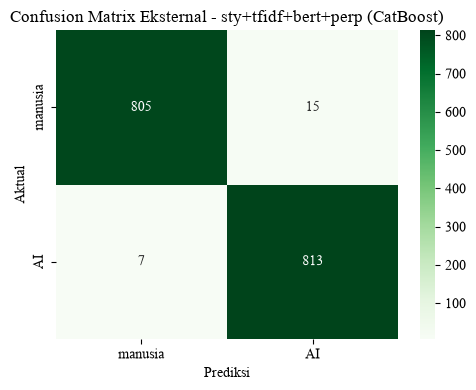


Disimpan: uji_eksternal_terbaik.csv + confusion_matrix_eksternal_terbaik.png


In [25]:
import os, time
import numpy as np, pandas as pd
from tqdm.auto import tqdm
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
    accuracy_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score)
import matplotlib.pyplot as plt
try:
    import seaborn as sns; _HAS_SNS = True
except Exception:
    _HAS_SNS = False
try:
    from IPython.display import display
except Exception:
    display = print

# --- pilih konfigurasi terbaik dari ringkasan Tahap 7.6 ---
best = ringkasan.iloc[0]
BEST_COMBO = best["kombinasi"].split("+")
BEST_MODEL = best["model"]
print(f"TERBAIK: {best['kombinasi']} + {BEST_MODEL} "
      f"(F1-macro={best['f1_macro_mean']:.4f} +/- {best['f1_macro_std']:.4f})")

# --- latih ulang pada SELURUH data internal ---
final_pipe = Pipeline([("pre", build_preprocessor_subset(BEST_COMBO, _SVD_K, _PCA_K)),
                       ("clf", make_models()[BEST_MODEL])])
final_pipe.fit(Xdf, y)
print(f"Model terbaik dilatih pada {len(y)} artikel internal.")

# --- nama fitur stylometry untuk menyusun kolom eksternal ---
try:
    sty_names
except NameError:
    sty_names = list(extract_stylometric_features(df["text"].iloc[0]).keys())

# --- muat & filter data eksternal ---
EXT_PATH = str(DATA_DIR / "berita_eksternal_clean_long.csv")
MIN_W = int(globals().get("MIN_ARTICLE_WORDS", 20))
ext = pd.read_csv(EXT_PATH); ext.columns = ext.columns.str.strip()
ext["text"] = ext["text"].astype(str).str.strip()
ext = ext[ext["text"].str.split().apply(len) >= MIN_W].reset_index(drop=True)
ext["label"] = ext["label"].astype(int)
print(f"Dataset eksternal: {ext.shape} | distribusi label: {ext['label'].value_counts().to_dict()}")

# --- ekstraksi fitur eksternal (pakai cache yang sama) ---
ECACHE = str(CACHE_DIR / "features_cache_eksternal"); os.makedirs(ECACHE, exist_ok=True)
ext_texts = ext["text"].tolist()

if os.path.exists(f"{ECACHE}/sty.npy"):
    sty_ext = np.load(f"{ECACHE}/sty.npy")
else:
    sty_ext = (pd.DataFrame([extract_stylometric_features(t) for t in tqdm(ext_texts, desc="sty-ext")])
               .reindex(columns=sty_names).values.astype(np.float32))
    np.save(f"{ECACHE}/sty.npy", sty_ext)

if os.path.exists(f"{ECACHE}/ppl.npy"):
    ppl_ext = np.load(f"{ECACHE}/ppl.npy")
else:
    ppl_ext = np.array([calculate_perplexity(t) for t in tqdm(ext_texts, desc="ppl-ext")], dtype=np.float32)
    np.save(f"{ECACHE}/ppl.npy", ppl_ext)

tfidf_ext = [preprocess_for_tfidf(t) for t in tqdm(ext_texts, desc="tfidf-ext")]

if os.path.exists(f"{ECACHE}/bert.npy"):
    bert_ext = np.load(f"{ECACHE}/bert.npy")
else:
    bert_ext = np.vstack([get_bert_embeddings(t) for t in tqdm(ext_texts, desc="bert-ext")]).astype(np.float32)
    np.save(f"{ECACHE}/bert.npy", bert_ext)

# --- susun matriks fitur eksternal dengan kolom & urutan SAMA seperti training ---
Xdf_ext = pd.DataFrame(bert_ext, columns=bert_cols)
Xdf_ext[sty_cols] = sty_ext
Xdf_ext["perplexity"] = ppl_ext
Xdf_ext["text"] = tfidf_ext
Xdf_ext = Xdf_ext[list(Xdf.columns)]
y_ext = ext["label"].values

# --- prediksi + confusion matrix TN/FP/FN/TP ---
y_pred = final_pipe.predict(Xdf_ext)
y_prob = final_pipe.predict_proba(Xdf_ext)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_ext, y_pred, labels=[0, 1]).ravel()

print("\n=== UJI EKSTERNAL - KOMBINASI + MODEL TERBAIK ===")
print(classification_report(y_ext, y_pred, target_names=["manusia", "AI"], digits=4))
print(f"TN (manusia diprediksi manusia) : {tn}")
print(f"FP (manusia diprediksi AI)      : {fp}")
print(f"FN (AI diprediksi manusia)      : {fn}")
print(f"TP (AI diprediksi AI)           : {tp}")
print(f"\nAkurasi {accuracy_score(y_ext, y_pred):.4f} | F1_AI {f1_score(y_ext, y_pred):.4f} | "
      f"Presisi_AI {precision_score(y_ext, y_pred):.4f} | Recall_AI {recall_score(y_ext, y_pred):.4f} | "
      f"ROC-AUC {roc_auc_score(y_ext, y_prob):.4f}")

# --- plot confusion matrix ---
cm = confusion_matrix(y_ext, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
if _HAS_SNS:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["manusia", "AI"], yticklabels=["manusia", "AI"])
else:
    plt.imshow(cm, cmap="Greens"); plt.colorbar()
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.xticks([0, 1], ["manusia", "AI"]); plt.yticks([0, 1], ["manusia", "AI"])
plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.title(f"Confusion Matrix Eksternal - {'+'.join(BEST_COMBO)} ({BEST_MODEL})")
plt.tight_layout(); plt.savefig(str(FIGURES_DIR / "confusion_matrix_eksternal_terbaik.png"), dpi=150); plt.show()

# --- simpan ringkasan ---
pd.DataFrame([{
    "kombinasi": "+".join(BEST_COMBO), "model": BEST_MODEL,
    "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    "akurasi": round(accuracy_score(y_ext, y_pred), 4),
    "f1_AI": round(f1_score(y_ext, y_pred), 4),
    "presisi_AI": round(precision_score(y_ext, y_pred), 4),
    "recall_AI": round(recall_score(y_ext, y_pred), 4),
    "roc_auc": round(roc_auc_score(y_ext, y_prob), 4),
}]).to_csv(str(RESULTS_DIR / "uji_eksternal_terbaik.csv"), index=False)
print("\nDisimpan: uji_eksternal_terbaik.csv + confusion_matrix_eksternal_terbaik.png")


In [26]:
# ===== Salah prediksi - UJI EKSTERNAL =====
LABEL_NAMA = {0: "manusia", 1: "AI"}

# 1) rangkai hasil (ext selaras dg y_ext / y_pred / y_prob)
hasil_ext = ext.copy().reset_index(drop=True)
hasil_ext["label_aktual"] = y_ext.astype(int)
hasil_ext["prediksi"]     = y_pred.astype(int)
hasil_ext["prob_AI"]      = np.round(y_prob, 4)
hasil_ext["benar"]        = hasil_ext["label_aktual"] == hasil_ext["prediksi"]

def _jenis_e(r):
    if r["benar"]:
        return "benar"
    return "FP (manusia dikira AI)" if r["label_aktual"] == 0 else "FN (AI dikira manusia)"
hasil_ext["jenis_kesalahan"]  = hasil_ext.apply(_jenis_e, axis=1)
hasil_ext["label_aktual_str"] = hasil_ext["label_aktual"].map(LABEL_NAMA)
hasil_ext["prediksi_str"]     = hasil_ext["prediksi"].map(LABEL_NAMA)
hasil_ext["cuplikan_teks"]    = hasil_ext["text"].astype(str).str.slice(0, 160)

# kolom generator bila tersedia (opsional, tergantung dataset)
_gen_col = next((c for c in ["generator", "model", "ai_model", "generator_model"]
                 if c in hasil_ext.columns), None)

kolom_e = ["id", "source"] + ([_gen_col] if _gen_col else []) + [
    "title", "label_aktual_str", "prediksi_str", "jenis_kesalahan",
    "prob_AI", "cuplikan_teks", "text"]
kolom_e = [c for c in kolom_e if c in hasil_ext.columns]

salah_ext = hasil_ext[~hasil_ext["benar"]].copy()
salah_ext["keyakinan_salah"] = (salah_ext["prob_AI"] - 0.5).abs()
salah_ext = salah_ext.sort_values("keyakinan_salah", ascending=False)[kolom_e]

hasil_ext[kolom_e].to_csv(str(RESULTS_DIR / "prediksi_eksternal_lengkap.csv"), index=False)
salah_ext.to_csv(str(RESULTS_DIR / "salah_prediksi_eksternal.csv"), index=False)

print("=== SALAH PREDIKSI - UJI EKSTERNAL ===")
print(f"Total salah tebak : {len(salah_ext)} dari {len(hasil_ext)} dokumen")
print(salah_ext["jenis_kesalahan"].value_counts().to_string())
print("\nKesalahan per penerbit:")
rekap = (hasil_ext.assign(salah=~hasil_ext["benar"])
         .groupby("source")
         .agg(total=("benar", "size"), salah=("salah", "sum")))
rekap["akurasi"] = (1 - rekap["salah"] / rekap["total"]).round(4)
print(rekap.to_string())
print("\nDisimpan: salah_prediksi_eksternal.csv + prediksi_eksternal_lengkap.csv")

=== SALAH PREDIKSI - UJI EKSTERNAL ===
Total salah tebak : 22 dari 1640 dokumen
jenis_kesalahan
FP (manusia dikira AI)    15
FN (AI dikira manusia)     7

Kesalahan per penerbit:
          total  salah  akurasi
source                         
Detik       460      7   0.9848
Kompas      686     10   0.9854
Liputan6    494      5   0.9899

Disimpan: salah_prediksi_eksternal.csv + prediksi_eksternal_lengkap.csv


In [27]:
# =====  - UJI EKSTERNAL: CatBoost salah vs model lain (fusi penuh) =====
from sklearn.pipeline import Pipeline
LABEL_NAMA = {0: "manusia", 1: "AI"}
MODEL_LAIN = ["XGBoost", "Random Forest"]

# preprocessor fusi penuh SAMA seperti Tahap 7.7
def _pre_full_ext():
    return build_preprocessor_subset(["sty", "tfidf", "bert", "perp"], _SVD_K, _PCA_K)

# 1) CatBoost: PAKAI ULANG y_pred/y_prob dari Tahap 7.7
ext_pred = {"CatBoost": (y_pred.astype(int), y_prob)}

# 2) XGBoost & RF: latih di SELURUH data internal, prediksi ke eksternal
for m in MODEL_LAIN:
    pipe = Pipeline([("pre", _pre_full_ext()), ("clf", make_models()[m])])
    pipe.fit(Xdf, y)
    ext_pred[m] = (pipe.predict(Xdf_ext).astype(int), pipe.predict_proba(Xdf_ext)[:, 1])
    print(f"[EKSTERNAL] {m} selesai.")

# 3) rangkai per-sampel (ext selaras dg y_ext)
re = ext.copy().reset_index(drop=True)
re["label_aktual"] = y_ext.astype(int)
re["cat_pred"] = ext_pred["CatBoost"][0]; re["cat_prob_AI"] = np.round(ext_pred["CatBoost"][1], 4)
re["xgb_pred"] = ext_pred["XGBoost"][0];  re["xgb_prob_AI"] = np.round(ext_pred["XGBoost"][1], 4)
re["rf_pred"]  = ext_pred["Random Forest"][0]; re["rf_prob_AI"] = np.round(ext_pred["Random Forest"][1], 4)

# 4) sampel yg CatBoost SALAH + kategori
re["cat_benar"] = re["label_aktual"] == re["cat_pred"]
salah_cat_e = re[~re["cat_benar"]].copy()
salah_cat_e["xgb_benar"] = salah_cat_e["label_aktual"] == salah_cat_e["xgb_pred"]
salah_cat_e["rf_benar"]  = salah_cat_e["label_aktual"] == salah_cat_e["rf_pred"]
def _kategori(r):
    if r["xgb_benar"] and r["rf_benar"]: return "tertolong XGB & RF"
    if r["xgb_benar"]:                   return "tertolong XGBoost saja"
    if r["rf_benar"]:                    return "tertolong RF saja"
    return "sulit (semua model salah)"
salah_cat_e["kategori"] = salah_cat_e.apply(_kategori, axis=1)
salah_cat_e["jenis_kesalahan_cat"] = np.where(
    salah_cat_e["label_aktual"] == 0, "FP (manusia dikira AI)", "FN (AI dikira manusia)")
salah_cat_e["label_aktual_str"] = salah_cat_e["label_aktual"].map(LABEL_NAMA)
salah_cat_e["cuplikan_teks"] = salah_cat_e["text"].astype(str).str.slice(0, 160)

kol_e = [c for c in ["id","source","title","label_aktual_str","jenis_kesalahan_cat","kategori",
         "cat_pred","cat_prob_AI","xgb_pred","xgb_prob_AI","rf_pred","rf_prob_AI",
         "cuplikan_teks","text"] if c in salah_cat_e.columns]
salah_cat_e = salah_cat_e.sort_values(["kategori", "cat_prob_AI"])[kol_e]
salah_cat_e.to_csv(str(RESULTS_DIR / "eksternal_catboost_salah.csv"), index=False)

ne = len(salah_cat_e); ne_t = int((salah_cat_e["kategori"] != "sulit (semua model salah)").sum())
print("\n===  - UJI EKSTERNAL ===")
print(f"CatBoost salah tebak : {ne} sampel")
print(salah_cat_e["kategori"].value_counts().to_string())
print(f"-> {ne_t}/{ne} tertolong model lain | {ne-ne_t}/{ne} sulit (semua salah)")
print("Disimpan: eksternal_catboost_salah.csv")

[EKSTERNAL] XGBoost selesai.
[EKSTERNAL] Random Forest selesai.

===  - UJI EKSTERNAL ===
CatBoost salah tebak : 22 sampel
kategori
sulit (semua model salah)    10
tertolong XGBoost saja        6
tertolong RF saja             4
tertolong XGB & RF            2
-> 12/22 tertolong model lain | 10/22 sulit (semua salah)
Disimpan: eksternal_catboost_salah.csv


In [28]:
# ===== EKSPOR ANALISIS KESALAHAN (#4 & #5) — memakai variabel yang sudah ada =====
import numpy as np, pandas as pd
from sklearn.metrics import f1_score

y_arr  = np.asarray(y).astype(int)
cat = np.asarray(oof["CatBoost"][0]).astype(int)
rf  = np.asarray(oof["Random Forest"][0]).astype(int)
xgb = np.asarray(oof["XGBoost"][0]).astype(int)

# id kanonik: news-{source_id}-{ai|human}
ids = np.array([f"news-{int(s)}-{'ai' if l==1 else 'human'}" for s, l in zip(groups, y_arr)])

# --- #4: profil kesalahan tiap model ---
rows = []
for nama, p in [("Random Forest", rf), ("XGBoost", xgb), ("CatBoost", cat)]:
    rows.append({"Model": nama,
                 "Total salah": int((p != y_arr).sum()),
                 "FP (manusia->AI)": int(((p == 1) & (y_arr == 0)).sum()),
                 "FN (AI->manusia)": int(((p == 0) & (y_arr == 1)).sum()),
                 "F1-macro": round(f1_score(y_arr, p, average="macro"), 4)})
profil = pd.DataFrame(rows)
profil.to_csv(str(RESULTS_DIR / "profil_kesalahan_model.csv"), index=False)
print("=== PROFIL KESALAHAN TIAP MODEL (OOF) ==="); print(profil.to_string(index=False))

# --- Taksonomi kesalahan CatBoost ---
cw = cat != y_arr
cats = np.array([""] * len(y_arr), dtype=object)
for i in np.where(cw)[0]:
    r, x = rf[i] == y_arr[i], xgb[i] == y_arr[i]
    cats[i] = ("Sulit (semua model salah)" if not r and not x else
               "Tertolong XGBoost & Random Forest" if r and x else
               "Tertolong Random Forest saja" if r else "Tertolong XGBoost saja")
print("\n=== TAKSONOMI CatBoost (total", int(cw.sum()), ") ===")
print(pd.Series(cats[cw]).value_counts().to_string())

# --- daftar dokumen salah CatBoost ---
to_str = lambda p: np.where(np.asarray(p).astype(int) == 1, "AI", "manusia")

# ambil cuplikan teks dari sumber mana pun yang tersedia
if "text" in df.columns:
    _teks = df["text"].astype(str).str[:200].values
elif "Xdf" in globals() and "text" in Xdf.columns:
    _teks = Xdf["text"].astype(str).str[:200].values
else:
    _teks = np.array([""] * len(y_arr))

out = pd.DataFrame({
    "id": ids, "source_id": groups, "label_asli": to_str(y_arr),
    "pred_random_forest": to_str(rf), "pred_xgboost": to_str(xgb), "pred_catboost": to_str(cat),
    "prob_catboost_ai": np.round(np.asarray(oof["CatBoost"][1]), 4),
    "kategori_kesalahan_catboost": cats,
    "teks": _teks,
})[cw].sort_values(["kategori_kesalahan_catboost", "id"]).reset_index(drop=True)
out.to_csv(str(RESULTS_DIR / "dokumen_salah_internal.csv"), index=False)
print("Dokumen salah CatBoost:", len(out), "(harus 97)")

=== PROFIL KESALAHAN TIAP MODEL (OOF) ===
        Model  Total salah  FP (manusia->AI)  FN (AI->manusia)  F1-macro
Random Forest          166                54               112    0.9722
      XGBoost          103                38                65    0.9828
     CatBoost           97                40                57    0.9838

=== TAKSONOMI CatBoost (total 97 ) ===
Sulit (semua model salah)            66
Tertolong Random Forest saja         20
Tertolong XGBoost & Random Forest     8
Tertolong XGBoost saja                3
Dokumen salah CatBoost: 97 (harus 97)


In [29]:
# ============================================================================
# SEL EKSPOR ARTEFAK MODEL  
# ============================================================================
import joblib
import sklearn
import catboost
from sklearn.pipeline import Pipeline

BEST_SVD, BEST_PCA = 300, 150   # konfigurasi terbaik (469 dim)

final_pipe = Pipeline([
    ("pre", build_preprocessor(BEST_SVD, BEST_PCA)),
    ("clf", make_models()["CatBoost"]),
])

# latih pada SELURUH data internal
final_pipe.fit(Xdf, y)

joblib.dump(final_pipe, str(MODELS_DIR / "model_detektor_catboost_469.joblib"))
print(" model_detektor_catboost_469.joblib tersimpan.")
print(" versi library :")
print("   scikit-learn =", sklearn.__version__)
print("   catboost     =", catboost.__version__)


 model_detektor_catboost_469.joblib tersimpan.
 versi library :
   scikit-learn = 1.9.0
   catboost     = 1.2.10


In [30]:
# Sel-sel berikut menyimpan hasil analisis tambahan ke RESULTS_DIR.
print("Folder keluaran :", str(RESULTS_DIR))

Folder keluaran : c:\Kuliah\SKRIPSI\setelah sempro\data_indo\push gihub\AI-Text-Detection\results


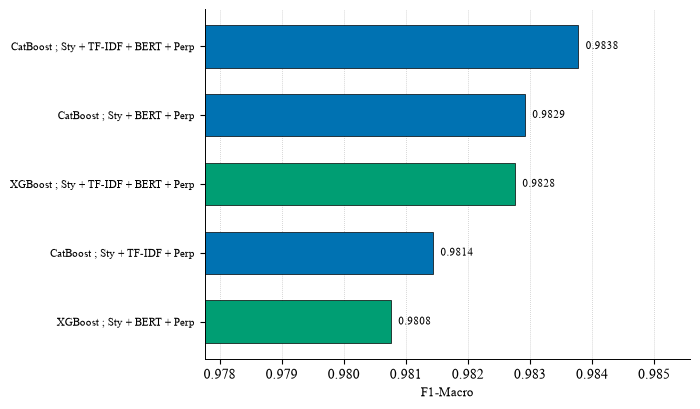

=== Lima konfigurasi terbaik ===
 rank    model           kombinasi              feature_label  n_fitur  f1_macro_mean  f1_macro_std
    1 CatBoost sty+tfidf+bert+perp Sty + TF-IDF + BERT + Perp        4        0.98378      0.001522
    2 CatBoost       sty+bert+perp          Sty + BERT + Perp        3        0.98292      0.002390
    3  XGBoost sty+tfidf+bert+perp Sty + TF-IDF + BERT + Perp        4        0.98276      0.001710
    4 CatBoost      sty+tfidf+perp        Sty + TF-IDF + Perp        3        0.98144      0.002240
    5  XGBoost       sty+bert+perp          Sty + BERT + Perp        3        0.98076      0.003904

Disimpan:
- c:\Kuliah\SKRIPSI\setelah sempro\data_indo\push gihub\AI-Text-Detection\results\top5_f1_macro.png
- c:\Kuliah\SKRIPSI\setelah sempro\data_indo\push gihub\AI-Text-Detection\results\top5_f1_macro.pdf


In [31]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


if "ringkasan" in globals() and isinstance(ringkasan, pd.DataFrame):
    _rank_df = ringkasan.copy()
else:
    _rank_df = pd.read_csv(str(RESULTS_DIR / "ringkasan_kombinasi_model.csv"))
_rank_df.columns = _rank_df.columns.str.strip()

_required = {"kombinasi", "n_fitur", "model", "f1_macro_mean"}
_missing = _required.difference(_rank_df.columns)
if _missing:
    raise ValueError(f"Kolom ringkasan kombinasi tidak lengkap: {sorted(_missing)}")

_rank_df = (_rank_df.drop_duplicates(["kombinasi", "model"])
             .sort_values(["f1_macro_mean", "model"], ascending=[False, True])
             .reset_index(drop=True))
_top5 = _rank_df.head(5).copy()

_feature_name = {
    "sty": "Sty",
    "tfidf": "TF-IDF",
    "bert": "BERT",
    "perp": "Perp",
}
def _feature_label(combo):
    return " + ".join(_feature_name[x] for x in str(combo).split("+"))

_top5["feature_label"] = _top5["kombinasi"].map(_feature_label)
_top5["plot_label"] = _top5["model"] + " ; " + _top5["feature_label"]
_top5["rank"] = np.arange(1, len(_top5) + 1)
_out_cols = [c for c in ["rank", "model", "kombinasi", "feature_label",
                         "n_fitur", "f1_macro_mean", "f1_macro_std"]
             if c in _top5.columns]
_top5[_out_cols].to_csv(
    os.path.join(str(RESULTS_DIR), "top5_konfigurasi.csv"), index=False
)

_plot = _top5.iloc[::-1].reset_index(drop=True)
_model_color = {
    "CatBoost": "#0072B2",
    "XGBoost": "#009E73",
    "Random Forest": "#E69F00",
}
_colors = [_model_color.get(x, "#777777") for x in _plot["model"]]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.linewidth": 0.7,
})
fig, ax = plt.subplots(figsize=(7.1, 4.2))
ypos = np.arange(len(_plot))
ax.barh(ypos, _plot["f1_macro_mean"], color=_colors,
        edgecolor="black", linewidth=0.5, height=0.62)
ax.set_yticks(ypos)
ax.set_yticklabels(_plot["plot_label"], fontsize=8)
ax.set_xlabel("F1-Macro", fontsize=9)
_xmin = max(0.0, float(_plot["f1_macro_mean"].min()) - 0.0030)
_xmax = min(1.0, float(_plot["f1_macro_mean"].max()) + 0.0018)
ax.set_xlim(_xmin, _xmax)
for i, value in enumerate(_plot["f1_macro_mean"]):
    ax.text(float(value) + 0.00012, i, f"{float(value):.4f}",
            va="center", ha="left", fontsize=8)
ax.grid(axis="x", linestyle=":", linewidth=0.55, color="0.75")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

_png = os.path.join(str(RESULTS_DIR), "top5_f1_macro.png")
_pdf = os.path.join(str(RESULTS_DIR), "top5_f1_macro.pdf")
fig.savefig(_png, dpi=300, bbox_inches="tight")
fig.savefig(_pdf, bbox_inches="tight")
plt.show()

print("=== Lima konfigurasi terbaik ===")
print(_top5[_out_cols].to_string(index=False))
print(f"\nDisimpan:\n- {_png}\n- {_pdf}")


In [32]:

import os
import itertools
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

_CKPT_DIR = os.path.join(str(RESULTS_DIR), "checkpoint_oof_catboost")
os.makedirs(_CKPT_DIR, exist_ok=True)

_required_globals = ["Xdf", "y", "groups", "gkf", "make_models",
                     "build_preprocessor_subset"]
_missing_globals = [x for x in _required_globals if x not in globals()]
if _missing_globals:
    raise RuntimeError(
        "Jalankan seluruh sel sampai Tahap 9 terlebih dahulu. Variabel belum ada: "
        + ", ".join(_missing_globals)
    )

_ABL_FEATURES = ["sty", "tfidf", "bert", "perp"]
_ABL_COMBOS = [list(c) for r in range(1, 5)
               for c in itertools.combinations(_ABL_FEATURES, r)]
_ABL_FULL = "+".join(_ABL_FEATURES)
_ABL_SVD = int(globals().get("BEST_SVD", globals().get("SVD_K", 300)))
_ABL_PCA = int(globals().get("BEST_PCA", globals().get("PCA_K", 150)))
_ABL_N = len(y)

# Identitas dokumen; source_id tidak unik karena satu peristiwa memiliki dua kelas.
if "train_df" in globals() and len(train_df) == _ABL_N and "doc_id" in train_df.columns:
    _doc_ids = train_df["doc_id"].astype(str).values
elif "df" in globals() and len(df) == _ABL_N and "id" in df.columns:
    _doc_ids = df["id"].astype(str).values
else:
    _doc_ids = np.array([
        f"news-{sid}-{'ai' if int(lab) == 1 else 'human'}"
        for sid, lab in zip(groups, y)
    ])

_base_oof = pd.DataFrame({
    "row_index": np.arange(_ABL_N, dtype=int),
    "doc_id": _doc_ids,
    "source_id": np.asarray(groups),
    "label_aktual": np.asarray(y).astype(int),
})

_r19_frames = []
for _combo in _ABL_COMBOS:
    _combo_name = "+".join(_combo)
    _safe_name = _combo_name.replace("+", "__")
    _ckpt_file = os.path.join(_CKPT_DIR, f"{_safe_name}.csv")

    _use_checkpoint = False
    if os.path.exists(_ckpt_file):
        try:
            _tmp = pd.read_csv(_ckpt_file)
            _use_checkpoint = (
                len(_tmp) == _ABL_N
                and set(["row_index", "prediksi", "probabilitas_AI"]).issubset(_tmp.columns)
                and _tmp["row_index"].astype(int).tolist() == list(range(_ABL_N))
            )
        except Exception:
            _use_checkpoint = False

    if _use_checkpoint:
        print(f"[checkpoint] {_combo_name}")
        _combo_df = _tmp.copy()
    else:
        _pred = np.zeros(_ABL_N, dtype=int)
        _prob = np.zeros(_ABL_N, dtype=float)

        # Fusi penuh dapat memakai ulang hasil OOF resmi Tahap 9.
        _reused_full = False
        if _combo_name == _ABL_FULL:
            if "oof_pred" in globals() and "oof_prob" in globals():
                if len(oof_pred) == _ABL_N and len(oof_prob) == _ABL_N:
                    _pred[:] = np.asarray(oof_pred).astype(int)
                    _prob[:] = np.asarray(oof_prob, dtype=float)
                    _reused_full = True
            if (not _reused_full) and "oof" in globals() and "CatBoost" in oof:
                _op, _ob = oof["CatBoost"]
                if len(_op) == _ABL_N and len(_ob) == _ABL_N:
                    _pred[:] = np.asarray(_op).astype(int)
                    _prob[:] = np.asarray(_ob, dtype=float)
                    _reused_full = True

        if _reused_full:
            print(f"[reuse OOF resmi] {_combo_name}")
        else:
            print(f"[hitung OOF] {_combo_name} ({len(_combo)} fitur)")
            for _fold, (_tr, _va) in enumerate(gkf.split(Xdf, y, groups), start=1):
                _pipe = Pipeline([
                    ("pre", build_preprocessor_subset(
                        _combo, _ABL_SVD, _ABL_PCA
                    )),
                    ("clf", make_models()["CatBoost"]),
                ])
                _pipe.fit(Xdf.iloc[_tr], np.asarray(y)[_tr])
                _pred[_va] = _pipe.predict(Xdf.iloc[_va]).astype(int)
                _prob[_va] = _pipe.predict_proba(Xdf.iloc[_va])[:, 1]
                print(f"  fold {_fold}/5 selesai")

        _combo_df = _base_oof.copy()
        _combo_df["kombinasi"] = _combo_name
        _combo_df["n_fitur"] = len(_combo)
        _combo_df["prediksi"] = _pred
        _combo_df["probabilitas_AI"] = _prob
        _combo_df["benar"] = _combo_df["prediksi"] == _combo_df["label_aktual"]
        _combo_df.to_csv(_ckpt_file, index=False)

    _r19_frames.append(_combo_df)

_r19_long = pd.concat(_r19_frames, ignore_index=True)
_r19_long.to_csv(
    os.path.join(str(RESULTS_DIR), "oof_catboost_15_kombinasi.csv"),
    index=False,
)

# Bentuk matriks prediksi: satu baris per dokumen, satu kolom per kombinasi.
_r19_pred = _r19_long.pivot(index="row_index", columns="kombinasi", values="prediksi")
_r19_prob = _r19_long.pivot(index="row_index", columns="kombinasi", values="probabilitas_AI")
_r19_meta = _base_oof.set_index("row_index").copy()
_r19_meta["prediksi_fusi_penuh"] = _r19_pred[_ABL_FULL].astype(int)
_r19_meta["probabilitas_AI_fusi_penuh"] = _r19_prob[_ABL_FULL].astype(float)
_r19_meta["fusi_penuh_benar"] = (
    _r19_meta["prediksi_fusi_penuh"] == _r19_meta["label_aktual"]
)
_r19_err = _r19_meta[~_r19_meta["fusi_penuh_benar"]].copy()
_n_full_err = len(_r19_err)
_EXPECTED_FULL_ERRORS = 97
if _ABL_N == 5979 and _n_full_err != _EXPECTED_FULL_ERRORS:
    print(
        "PERINGATAN: kesalahan fusi penuh yang diperoleh adalah "
        f"{_n_full_err}, bukan {_EXPECTED_FULL_ERRORS}. "
        "Periksa kesesuaian sebelum menggunakan hasil ini "
        "dataset, pembagian fold, random_state, dan versi library."
    )

_summary_combo = []
_alt_combos = ["+".join(c) for c in _ABL_COMBOS if "+".join(c) != _ABL_FULL]
for _alt in _alt_combos:
    _n_feat = len(_alt.split("+"))
    _correct_alt = (
        _r19_pred.loc[_r19_err.index, _alt].astype(int).values
        == _r19_err["label_aktual"].astype(int).values
    )
    _rescued = int(_correct_alt.sum())
    _summary_combo.append({
        "kombinasi": _alt,
        "n_fitur": _n_feat,
        "dokumen_fusi_penuh_salah_yang_diselamatkan": _rescued,
        "persen_dari_error_fusi_penuh": (
            100.0 * _rescued / _n_full_err if _n_full_err else 0.0
        ),
    })
_summary_combo = (pd.DataFrame(_summary_combo)
                  .sort_values(["dokumen_fusi_penuh_salah_yang_diselamatkan",
                                "n_fitur"], ascending=[False, True])
                  .reset_index(drop=True))
_summary_combo.to_csv(
    os.path.join(str(RESULTS_DIR), "ringkasan_oof_per_kombinasi.csv"),
    index=False,
)

# Detail rescue per dokumen dan agregasi unik berdasarkan jumlah fitur.
_rescue_lists = []
for _idx, _row in _r19_err.iterrows():
    _rescued_by = [
        c for c in _alt_combos
        if int(_r19_pred.loc[_idx, c]) == int(_row["label_aktual"])
    ]
    _rescue_lists.append(_rescued_by)
_r19_err["kombinasi_penyelamat"] = ["; ".join(x) for x in _rescue_lists]
for _k in [3, 2, 1]:
    _r19_err[f"diselamatkan_konfigurasi_{_k}_fitur"] = [
        any(len(c.split("+")) == _k for c in lst) for lst in _rescue_lists
    ]
_r19_err["jumlah_kombinasi_penyelamat"] = [len(x) for x in _rescue_lists]
_r19_err["tetap_salah_di_semua_konfigurasi_alternatif"] = (
    _r19_err["jumlah_kombinasi_penyelamat"] == 0
)

_summary_size = []
for _k in [3, 2, 1]:
    _count = int(_r19_err[f"diselamatkan_konfigurasi_{_k}_fitur"].sum())
    _summary_size.append({
        "jumlah_fitur": _k,
        "dokumen_unik_diselamatkan_oleh_minimal_satu_konfigurasi": _count,
        "persen_dari_error_fusi_penuh": (
            100.0 * _count / _n_full_err if _n_full_err else 0.0
        ),
    })
_summary_size = pd.DataFrame(_summary_size)
_summary_size.to_csv(
    os.path.join(str(RESULTS_DIR), "ringkasan_oof_per_jumlah_fitur.csv"),
    index=False,
)
_r19_err.reset_index().to_csv(
    os.path.join(str(RESULTS_DIR), "detail_dokumen_fusi_penuh_salah.csv"),
    index=False,
)

print("\n=== ANALISIS OOF CATBOOST PER KOMBINASI FITUR — HASIL UTAMA ===")
print(f"Kesalahan OOF CatBoost fusi penuh: {_n_full_err} dokumen")
print("\nDokumen unik yang diselamatkan menurut ukuran konfigurasi:")
print(_summary_size.to_string(index=False))
print("\nSepuluh konfigurasi penyelamat terbanyak:")
print(_summary_combo.head(10).to_string(index=False))
_persistent = int(_r19_err["tetap_salah_di_semua_konfigurasi_alternatif"].sum())
_any_rescued = _n_full_err - _persistent
print(f"\nDiselamatkan minimal satu konfigurasi alternatif: {_any_rescued}")
print(f"Tetap salah pada seluruh konfigurasi alternatif: {_persistent}")
print(f"\nSeluruh output disimpan di: {str(RESULTS_DIR)}")


[checkpoint] sty
[checkpoint] tfidf
[checkpoint] bert
[checkpoint] perp
[checkpoint] sty+tfidf
[checkpoint] sty+bert
[checkpoint] sty+perp
[checkpoint] tfidf+bert
[checkpoint] tfidf+perp
[checkpoint] bert+perp
[checkpoint] sty+tfidf+bert
[checkpoint] sty+tfidf+perp
[checkpoint] sty+bert+perp
[checkpoint] tfidf+bert+perp
[checkpoint] sty+tfidf+bert+perp

=== ANALISIS OOF CATBOOST PER KOMBINASI FITUR — HASIL UTAMA ===
Kesalahan OOF CatBoost fusi penuh: 97 dokumen

Dokumen unik yang diselamatkan menurut ukuran konfigurasi:
 jumlah_fitur  dokumen_unik_diselamatkan_oleh_minimal_satu_konfigurasi  persen_dari_error_fusi_penuh
            3                                                       68                     70.103093
            2                                                       82                     84.536082
            1                                                       90                     92.783505

Sepuluh konfigurasi penyelamat terbanyak:
      kombinasi  n_fitur  d

[reuse OOF] Random Forest
[reuse OOF] XGBoost
[reuse OOF] CatBoost

=== MATRIKS EVALUASI OOF — FUSI PENUH 469 DIMENSI ===
               Accuracy  Balanced Accuracy  F1-Macro  ROC-AUC  Precision AI  Recall AI   F1 AI  Precision Human  Recall Human / Specificity  F1 Human    TN  FP   FN    TP  Total Errors
Model                                                                                                                                                                                   
Random Forest    0.9722             0.9723    0.9722   0.9967        0.9816     0.9627  0.9721           0.9631                      0.9819    0.9724  2925  54  112  2888           166
XGBoost          0.9828             0.9828    0.9828   0.9986        0.9872     0.9783  0.9828           0.9784                      0.9872    0.9828  2941  38   65  2935           103
CatBoost         0.9838             0.9838    0.9838   0.9983        0.9866     0.9810  0.9838           0.9810                      0.986

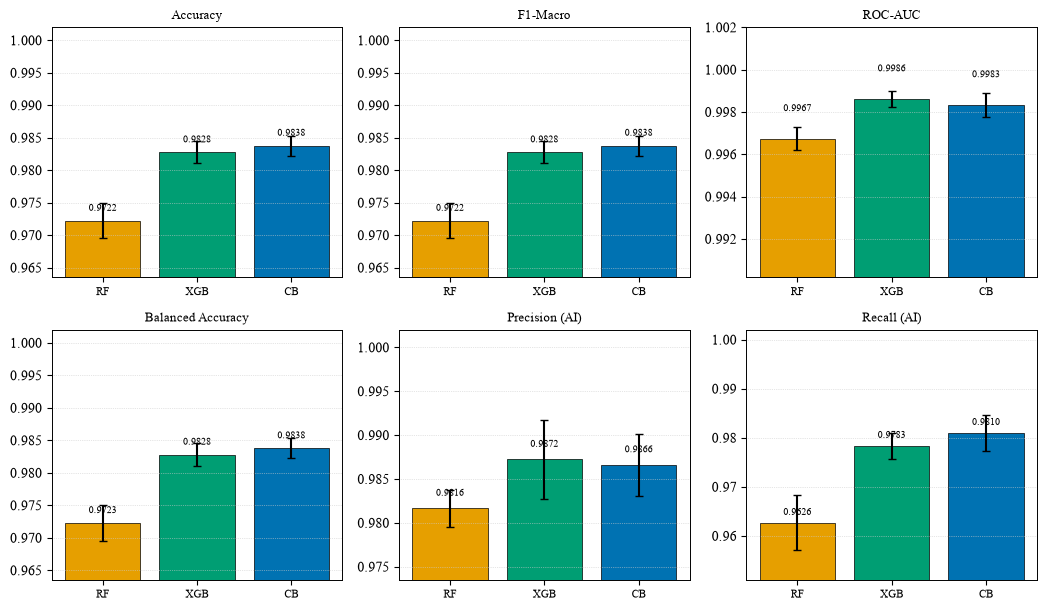

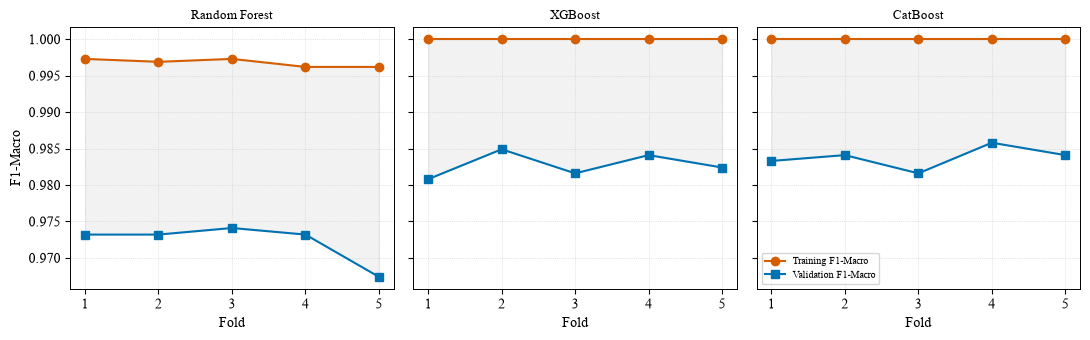


Seluruh tabel dan gambar disimpan di: c:\Kuliah\SKRIPSI\setelah sempro\data_indo\push gihub\AI-Text-Detection\results


In [33]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)

_EVAL_MODELS = ["Random Forest", "XGBoost", "CatBoost"]
_EVAL_SCORING_COLS = [
    "accuracy", "f1_macro", "roc_auc", "balanced_accuracy",
    "precision", "recall", "train_f1_macro", "gap_f1_macro",
]

# ---------------------------------------------------------------------------
# 1) Ambil metrik per fold dari Tahap 7; hitung ulang hanya bila belum tersedia.
# ---------------------------------------------------------------------------
_required_fold_cols = set(["model", "fold"] + _EVAL_SCORING_COLS)
# Variabel `perfold_df` dapat tertimpa oleh Tahap 8 (studi kombinasi), sehingga
# hanya dipakai bila benar-benar memiliki skema hasil fusi penuh Tahap 7.
if ("perfold_df" in globals() and isinstance(perfold_df, pd.DataFrame)
        and _required_fold_cols.issubset(perfold_df.columns)):
    _fold_data = perfold_df.copy()
else:
    _fold_data = pd.read_csv(str(RESULTS_DIR / "kinerja_per_fold.csv"))
_fold_data.columns = _fold_data.columns.str.strip()

_missing_cols = _required_fold_cols.difference(_fold_data.columns)
if _missing_cols:
    raise ValueError(
        "kinerja_per_fold.csv belum lengkap. Jalankan Tahap 7. Kolom hilang: "
        + ", ".join(sorted(_missing_cols))
    )
_fold_data = _fold_data[_fold_data["model"].isin(_EVAL_MODELS)].copy()
_fold_data = _fold_data.sort_values(["model", "fold"]).reset_index(drop=True)
_fold_data.to_csv(
    os.path.join(str(RESULTS_DIR), "kinerja_per_fold_full_fusion.csv"),
    index=False,
)

# Gunakan simpangan baku sampel (ddof=1), konsisten dengan pelaporan standar.
_metric_labels = {
    "accuracy": "Accuracy",
    "f1_macro": "F1-Macro",
    "roc_auc": "ROC-AUC",
    "balanced_accuracy": "Balanced Accuracy",
    "precision": "Precision (AI)",
    "recall": "Recall (AI)",
    "train_f1_macro": "Training F1-Macro",
    "gap_f1_macro": "Train–Validation Gap",
}
_summary_rows = []
for _model in _EVAL_MODELS:
    _g = _fold_data[_fold_data["model"] == _model]
    for _col in _EVAL_SCORING_COLS:
        _summary_rows.append({
            "model": _model,
            "metric": _metric_labels[_col],
            "mean": float(_g[_col].mean()),
            "sd": float(_g[_col].std(ddof=1)),
            "mean_sd": f"{_g[_col].mean():.4f} ± {_g[_col].std(ddof=1):.4f}",
        })
_summary_cv = pd.DataFrame(_summary_rows)
_summary_cv.to_csv(
    os.path.join(str(RESULTS_DIR), "ringkasan_cv_mean_sd.csv"),
    index=False,
)

# ---------------------------------------------------------------------------
# 2) Pastikan prediksi OOF fusi penuh tersedia untuk ketiga model.
# ---------------------------------------------------------------------------
_required = ["Xdf", "y", "groups", "gkf", "make_models", "build_preprocessor"]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise RuntimeError("Variabel pipeline belum tersedia: " + ", ".join(_missing))

_N_SAMPLES = len(y)
_oof_eval = {}
if "oof" in globals() and isinstance(oof, dict):
    for _m in _EVAL_MODELS:
        if _m in oof:
            _p, _b = oof[_m]
            if len(_p) == _N_SAMPLES and len(_b) == _N_SAMPLES:
                _oof_eval[_m] = (np.asarray(_p).astype(int), np.asarray(_b, dtype=float))

# Fallback: latih hanya model yang prediksi OOF-nya belum tersedia.
for _model in _EVAL_MODELS:
    if _model in _oof_eval:
        print(f"[reuse OOF] {_model}")
        continue
    print(f"[hitung OOF fusi penuh] {_model}")
    _pred = np.zeros(_N_SAMPLES, dtype=int)
    _prob = np.zeros(_N_SAMPLES, dtype=float)
    for _fold, (_tr, _va) in enumerate(gkf.split(Xdf, y, groups), start=1):
        _pipe = Pipeline([
            ("pre", build_preprocessor(
                int(globals().get("BEST_SVD", 300)),
                int(globals().get("BEST_PCA", 150)),
            )),
            ("clf", make_models()[_model]),
        ])
        _pipe.fit(Xdf.iloc[_tr], np.asarray(y)[_tr])
        _pred[_va] = _pipe.predict(Xdf.iloc[_va]).astype(int)
        _prob[_va] = _pipe.predict_proba(Xdf.iloc[_va])[:, 1]
        print(f"  fold {_fold}/5 selesai")
    _oof_eval[_model] = (_pred, _prob)

# ---------------------------------------------------------------------------
# 3) Matriks evaluasi OOF lengkap untuk ketiga model fusi penuh.
# ---------------------------------------------------------------------------
_oof_rows = []
for _model in _EVAL_MODELS:
    _pred, _prob = _oof_eval[_model]
    _tn, _fp, _fn, _tp = confusion_matrix(y, _pred, labels=[0, 1]).ravel()
    _precision_h = _tn / max(_tn + _fn, 1)
    _recall_h = _tn / max(_tn + _fp, 1)  # specificity / recall manusia
    _oof_rows.append({
        "Model": _model,
        "Accuracy": accuracy_score(y, _pred),
        "Balanced Accuracy": balanced_accuracy_score(y, _pred),
        "F1-Macro": f1_score(y, _pred, average="macro"),
        "ROC-AUC": roc_auc_score(y, _prob),
        "Precision AI": precision_score(y, _pred, pos_label=1, zero_division=0),
        "Recall AI": recall_score(y, _pred, pos_label=1, zero_division=0),
        "F1 AI": f1_score(y, _pred, pos_label=1, zero_division=0),
        "Precision Human": _precision_h,
        "Recall Human / Specificity": _recall_h,
        "F1 Human": f1_score(y, _pred, pos_label=0, zero_division=0),
        "TN": int(_tn), "FP": int(_fp), "FN": int(_fn), "TP": int(_tp),
        "Total Errors": int(_fp + _fn),
    })
_oof_matrix = pd.DataFrame(_oof_rows).set_index("Model")
_num_metric_cols = [c for c in _oof_matrix.columns
                    if c not in ["TN", "FP", "FN", "TP", "Total Errors"]]
_oof_matrix[_num_metric_cols] = _oof_matrix[_num_metric_cols].round(4)
_oof_matrix.to_csv(
    os.path.join(str(RESULTS_DIR), "matriks_evaluasi_oof_3model.csv"),
    encoding="utf-8-sig",
)

# Matriks ringkas: baris metrik, kolom model, memadukan CV mean±SD dan OOF.
_complete_rows = []
for _metric in _metric_labels.values():
    _row = {"Metric": f"CV {_metric} (mean ± SD)"}
    for _model in _EVAL_MODELS:
        _v = _summary_cv[
            (_summary_cv["model"] == _model) & (_summary_cv["metric"] == _metric)
        ]["mean_sd"].iloc[0]
        _row[_model] = _v
    _complete_rows.append(_row)
for _metric in _oof_matrix.columns:
    _row = {"Metric": f"OOF {_metric}"}
    for _model in _EVAL_MODELS:
        _value = _oof_matrix.loc[_model, _metric]
        if _metric in ["TN", "FP", "FN", "TP", "Total Errors"]:
            _row[_model] = str(int(_value))
        else:
            _row[_model] = f"{float(_value):.4f}"
    _complete_rows.append(_row)
_eval_matrix = pd.DataFrame(_complete_rows).set_index("Metric")
_eval_matrix.to_csv(
    os.path.join(str(RESULTS_DIR), "matriks_evaluasi_lengkap_3model.csv"),
    encoding="utf-8-sig",
)

print("\n=== MATRIKS EVALUASI OOF — FUSI PENUH 469 DIMENSI ===")
print(_oof_matrix.to_string())
print("\n=== RINGKASAN CV MEAN ± SD ===")
print(_eval_matrix.iloc[:len(_metric_labels)].to_string())

# ---------------------------------------------------------------------------
# 4) Grafik mean ± SD untuk enam metrik validasi.
# ---------------------------------------------------------------------------
_plot_metrics = [
    "Accuracy", "F1-Macro", "ROC-AUC", "Balanced Accuracy",
    "Precision (AI)", "Recall (AI)",
]
_colors = {"Random Forest": "#E69F00", "XGBoost": "#009E73", "CatBoost": "#0072B2"}
fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.2), sharey=False)
for _ax, _metric in zip(axes.ravel(), _plot_metrics):
    _sub = _summary_cv[_summary_cv["metric"] == _metric].set_index("model").loc[_EVAL_MODELS]
    _x = np.arange(len(_EVAL_MODELS))
    _ax.bar(_x, _sub["mean"], yerr=_sub["sd"], capsize=3,
            color=[_colors[m] for m in _EVAL_MODELS],
            edgecolor="black", linewidth=0.5)
    _ax.set_title(_metric, fontsize=9)
    _ax.set_xticks(_x)
    _ax.set_xticklabels(["RF", "XGB", "CB"], fontsize=8)
    _low = max(0.0, float((_sub["mean"] - _sub["sd"]).min()) - 0.006)
    _ax.set_ylim(_low, 1.002)
    _ax.grid(axis="y", linestyle=":", linewidth=0.5, color="0.8")
    for _i, _v in enumerate(_sub["mean"]):
        _ax.text(_i, min(1.000, float(_v) + 0.0012), f"{float(_v):.4f}",
                 ha="center", va="bottom", fontsize=7)
fig.tight_layout()
_metric_fig = os.path.join(str(RESULTS_DIR), "metrik_validasi_mean_sd.png")
fig.savefig(_metric_fig, dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# 5) Grafik F1-Macro pelatihan vs validasi per fold.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.5), sharey=True)
for _ax, _model in zip(axes, _EVAL_MODELS):
    _g = _fold_data[_fold_data["model"] == _model].sort_values("fold")
    _ax.plot(_g["fold"], _g["train_f1_macro"], marker="o", linewidth=1.5,
             label="Training F1-Macro", color="#D55E00")
    _ax.plot(_g["fold"], _g["f1_macro"], marker="s", linewidth=1.5,
             label="Validation F1-Macro", color="#0072B2")
    _ax.fill_between(_g["fold"], _g["f1_macro"], _g["train_f1_macro"],
                     alpha=0.10, color="gray")
    _ax.set_title(_model, fontsize=9)
    _ax.set_xlabel("Fold")
    _ax.set_xticks(_g["fold"])
    _ax.grid(linestyle=":", linewidth=0.5, color="0.8")
axes[0].set_ylabel("F1-Macro")
axes[-1].legend(fontsize=7, loc="lower left")
fig.tight_layout()
_train_fig = os.path.join(str(RESULTS_DIR), "train_vs_validation_f1_per_fold.png")
fig.savefig(_train_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSeluruh tabel dan gambar disimpan di: {RESULTS_DIR}")
